In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, GlobalAveragePooling1D, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

import pickle
import os
import json
from datetime import datetime

In [55]:
btc_5years = pd.read_csv('BTC_USDT_5_years.csv')
btc_5years.set_index('date', inplace = True)

eth_5years = pd.read_csv('ETH_USDT_5_years.csv')
eth_5years.set_index('date', inplace = True)

ltc_5years = pd.read_csv('LTC_USDT_5_years.csv')
ltc_5years.set_index('date', inplace = True)

xrp_5years = pd.read_csv('XRP_USDT_5_years.csv')
xrp_5years.set_index('date', inplace = True)

## XGBOOST + LSTM (WEIGHED)

In [56]:
def train_ensemble_model(
    data,
    forecast_days=30,
    lags=20,
    lookback=20,
    xgb_weight=0.5,
    lstm_weight=0.5
):

    # ==================================================
    # FEATURES
    # ==================================================

    feature_cols = [
        c for c in data.columns
        if c != "close"
    ]

    # ==================================================
    # XGBOOST DATASET
    # ==================================================

    price = data["close"].values

    X_xgb = []
    y_xgb = []

    for i in range(
        lags,
        len(data) - forecast_days
    ):

        row = []

        # ---------------- PRICE LAGS ----------------

        row.extend(
            price[i-lags:i]
        )

        # ---------------- FEATURE LAGS ----------------

        for col in feature_cols:

            row.extend(
                data[col].values[i-lags:i]
            )

        # ---------------- FUTURE TARGET ----------------

        future = price[
            i:i+forecast_days
        ]

        X_xgb.append(row)

        y_xgb.append(future)

    X_xgb = np.array(X_xgb)

    y_xgb = np.array(y_xgb)

    # ==================================================
    # LSTM DATASET
    # ==================================================

    scaler = MinMaxScaler()

    scaled_data = scaler.fit_transform(
        data.values
    )

    X_lstm = []
    y_lstm = []

    for i in range(
        lookback,
        len(scaled_data) - forecast_days
    ):

        X_lstm.append(
            scaled_data[
                i-lookback:i
            ]
        )

        # FUTURE CLOSES

        future = scaled_data[
            i:i+forecast_days,
            0
        ]

        y_lstm.append(future)

    X_lstm = np.array(X_lstm)

    y_lstm = np.array(y_lstm)

    # ==================================================
    # ALIGN
    # ==================================================

    min_len = min(
        len(X_xgb),
        len(X_lstm)
    )

    X_xgb = X_xgb[-min_len:]
    y_xgb = y_xgb[-min_len:]

    X_lstm = X_lstm[-min_len:]
    y_lstm = y_lstm[-min_len:]

    # ==================================================
    # SPLIT
    # ==================================================

    split = int(len(X_xgb) * 0.8)

    X_xgb_train = X_xgb[:split]
    X_xgb_test = X_xgb[split:]

    y_train = y_xgb[:split]
    y_test = y_xgb[split:]

    X_lstm_train = X_lstm[:split]
    X_lstm_test = X_lstm[split:]

    y_lstm_train = y_lstm[:split]

    # ==================================================
    # XGBOOST
    # ==================================================

    print("Training XGBoost...")

    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    xgb.fit(
        X_xgb_train,
        y_train
    )

    xgb_pred = xgb.predict(
        X_xgb_test
    )

    # ==================================================
    # LSTM
    # ==================================================

    print("Training LSTM...")

    n_features = data.shape[1]

    lstm = Sequential([

        Input(
            shape=(lookback, n_features)
        ),

        LSTM(
            64,
            return_sequences=True
        ),

        Dropout(0.2),

        LSTM(32),

        Dropout(0.2),

        Dense(
            64,
            activation="relu"
        ),

        Dense(forecast_days)
    ])

    lstm.compile(
        optimizer="adam",
        loss="mse"
    )

    lstm.fit(
        X_lstm_train,
        y_lstm_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
        callbacks=[
            EarlyStopping(
                patience=5,
                restore_best_weights=True
            )
        ]
    )

    # ==================================================
    # LSTM PRED
    # ==================================================

    lstm_scaled_pred = lstm.predict(
        X_lstm_test,
        verbose=0
    )

    lstm_pred = []

    for pred in lstm_scaled_pred:

        dummy = np.zeros(
            (forecast_days, n_features)
        )

        dummy[:, 0] = pred

        restored = scaler.inverse_transform(
            dummy
        )[:, 0]

        lstm_pred.append(restored)

    lstm_pred = np.array(lstm_pred)

    # ==================================================
    # ENSEMBLE
    # ==================================================

    hybrid_pred = (
        xgb_weight * xgb_pred +
        lstm_weight * lstm_pred
    )

    # ==================================================
    # METRICS
    # ==================================================

    xgb_mape = (
        mean_absolute_percentage_error(
            y_test.flatten(),
            xgb_pred.flatten()
        ) * 100
    )

    lstm_mape = (
        mean_absolute_percentage_error(
            y_test.flatten(),
            lstm_pred.flatten()
        ) * 100
    )

    hybrid_mape = (
        mean_absolute_percentage_error(
            y_test.flatten(),
            hybrid_pred.flatten()
        ) * 100
    )

    mae = mean_absolute_error(
        y_test.flatten(),
        hybrid_pred.flatten()
    )

    # ==================================================
    # RESULTS
    # ==================================================

    print("\n📊 RESULTS")

    print(f"XGB MAPE:      {xgb_mape:.2f}%")
    print(f"LSTM MAPE:     {lstm_mape:.2f}%")
    print(f"ENSEMBLE:      {hybrid_mape:.2f}%")
    print(f"MAE:           ${mae:,.2f}")

    # ==================================================
    # PLOT
    # ==================================================

    plt.figure(figsize=(14, 6))

    plt.plot(
        y_test[-1],
        label="Actual",
        linewidth=2
    )

    plt.plot(
        hybrid_pred[-1],
        label="Ensemble",
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"Multi-Output Forecast | "
        f"MAPE={hybrid_mape:.2f}%"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

    return {

        "predictions": hybrid_pred,

        "actual": y_test,

        "xgb_pred": xgb_pred,

        "lstm_pred": lstm_pred,

        "mape": hybrid_mape,

        "mae": mae,

        "models": {

            "xgb": xgb,

            "lstm": lstm,

            "scaler": scaler
        },

        "metadata": {

            "lags": lags,

            "lookback": lookback,

            "forecast_days": forecast_days,

            "feature_cols": feature_cols,

            "xgb_weight": xgb_weight,

            "lstm_weight": lstm_weight
        }
    }

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      19.31%
LSTM MAPE:     16.69%
ENSEMBLE:      18.03%
MAE:           $18,336.07


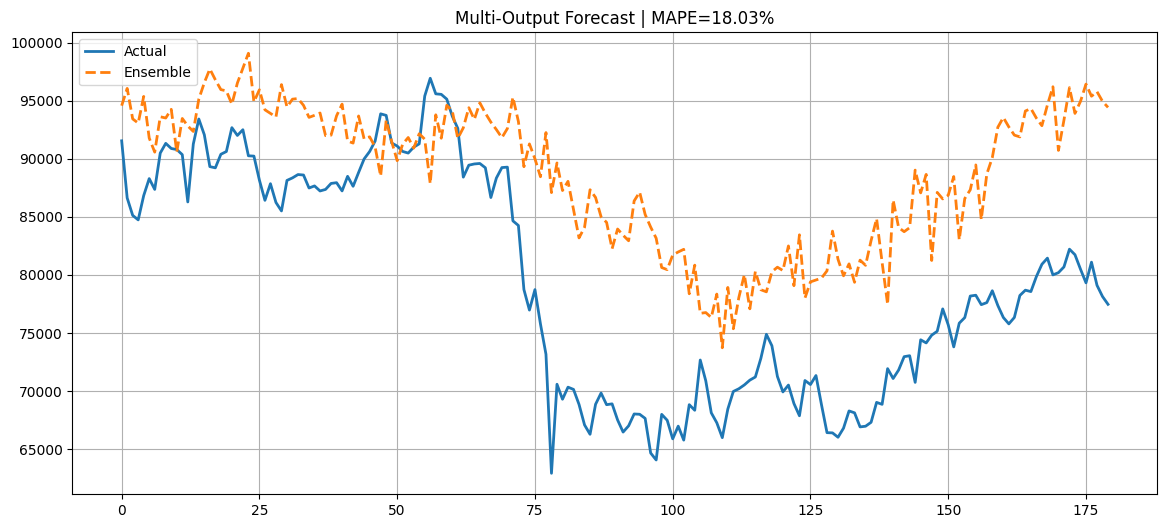

In [57]:
btc_xgb_lstm = train_ensemble_model(
    data=btc_5years,
    forecast_days=180,
    lags=20,
    lookback=20,
    xgb_weight=0.7,
    lstm_weight=0.3
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      11.82%
LSTM MAPE:     20.48%
ENSEMBLE:      13.82%
MAE:           $14,253.48


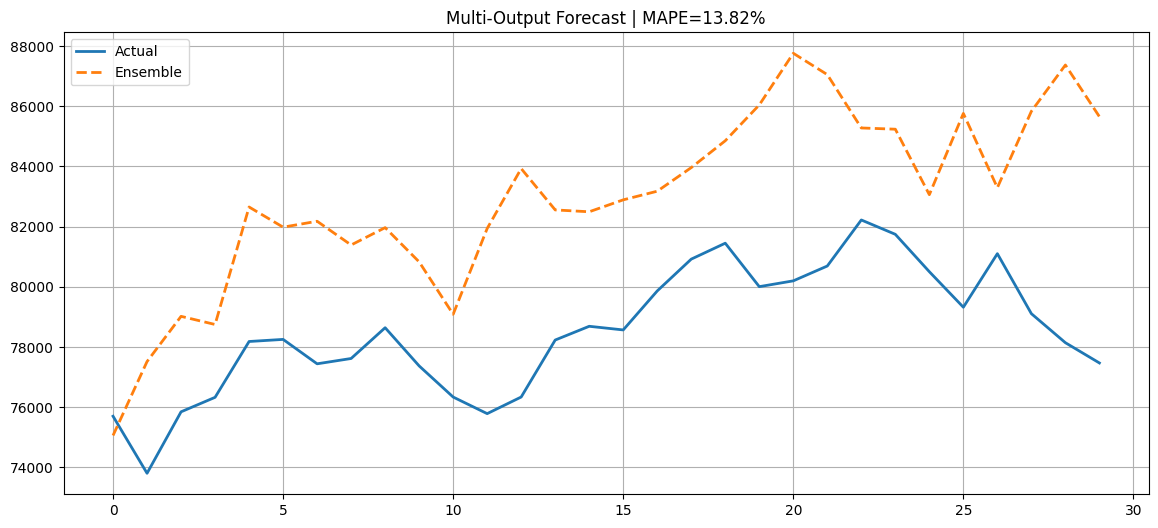

In [58]:
btc_xgb_lstm_30 = train_ensemble_model(
    data=btc_5years,
    forecast_days=30,
    lags=20,
    lookback=20,
    xgb_weight=0.7,
    lstm_weight=0.3
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      28.91%
LSTM MAPE:     26.70%
ENSEMBLE:      26.85%
MAE:           $833.04


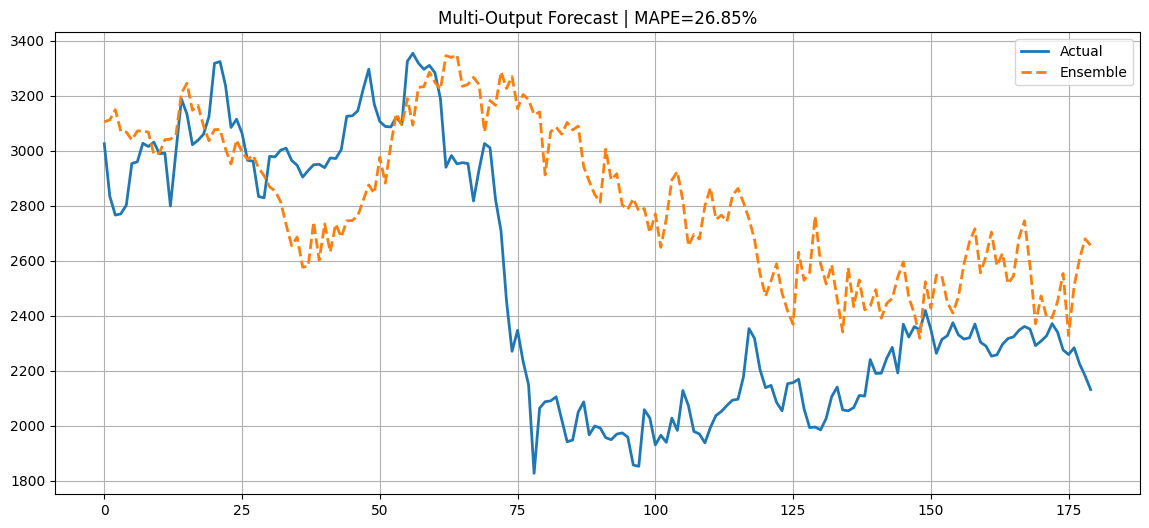

In [59]:
eth_xgb_lstm = train_ensemble_model(
    data=eth_5years,
    forecast_days=180,
    lags=20,
    lookback=20,
    xgb_weight=0.6,
    lstm_weight=0.4
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      10.90%
LSTM MAPE:     14.37%
ENSEMBLE:      10.88%
MAE:           $325.54


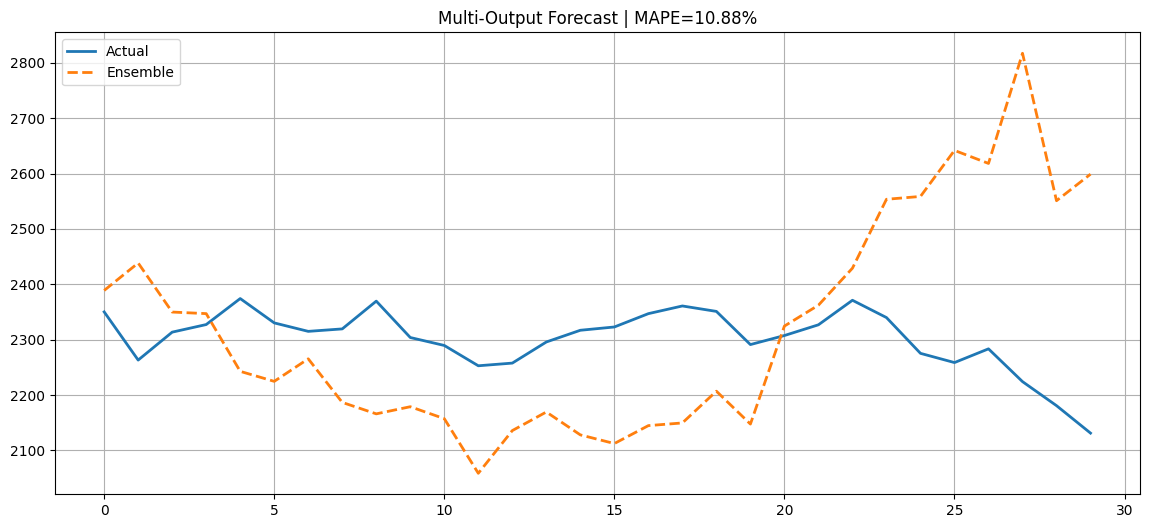

In [60]:
eth_xgb_lstm_30 = train_ensemble_model(
    data=eth_5years,
    forecast_days=30,
    lags=20,
    lookback=20,
    xgb_weight=0.7,
    lstm_weight=0.3
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      20.95%
LSTM MAPE:     33.30%
ENSEMBLE:      20.58%
MAE:           $0.52


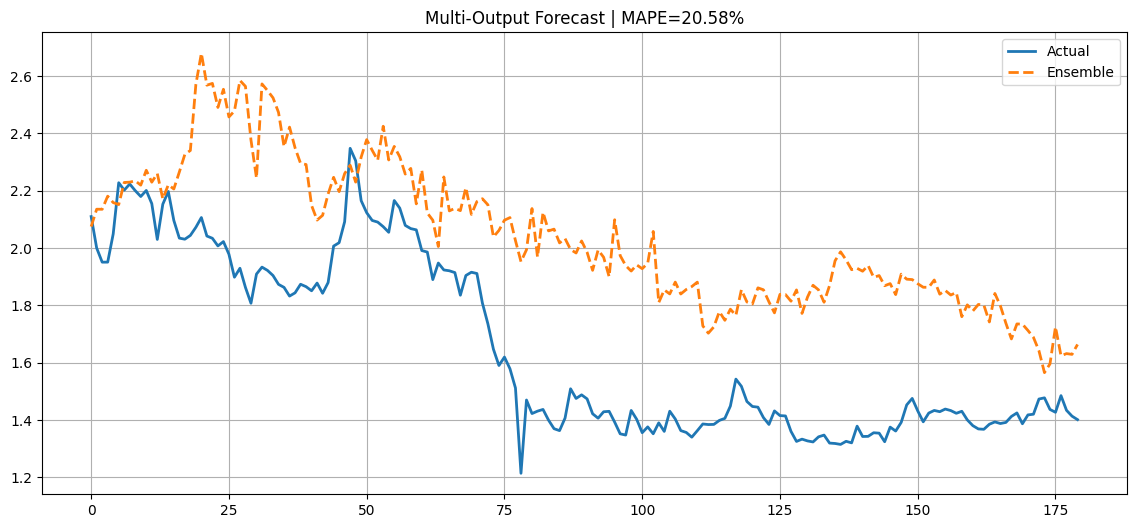

In [61]:
xrp_xgb_lstm = train_ensemble_model(
    data=xrp_5years,
    forecast_days=180,
    lags=20,
    lookback=20,
    xgb_weight=0.6,
    lstm_weight=0.4
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      22.44%
LSTM MAPE:     14.40%
ENSEMBLE:      18.73%
MAE:           $0.38


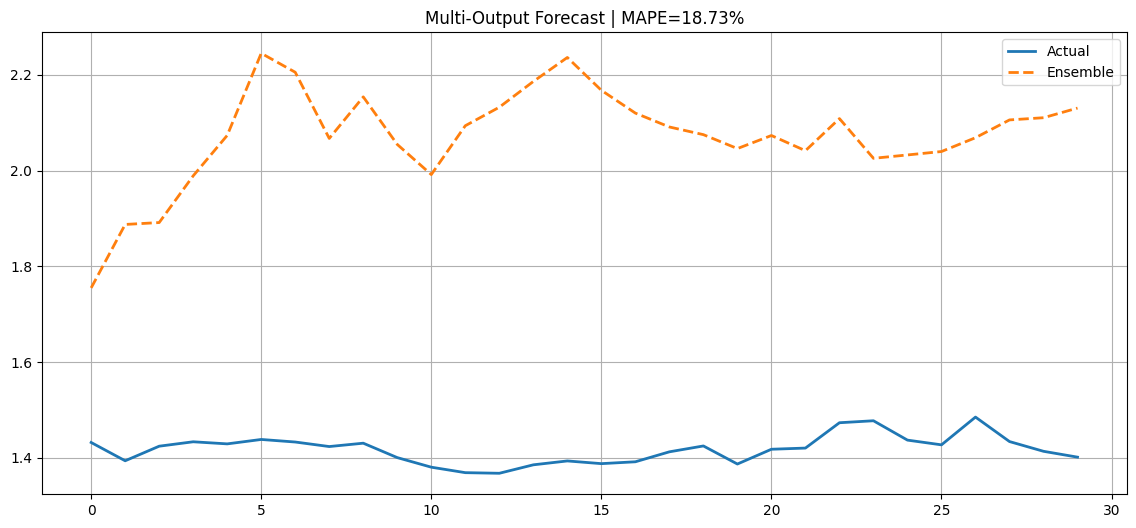

In [62]:
xrp_xgb_lstm_30 = train_ensemble_model(
    data=xrp_5years,
    forecast_days=30,
    lags=20,
    lookback=20,
    xgb_weight=0.7,
    lstm_weight=0.3
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      18.11%
LSTM MAPE:     19.75%
ENSEMBLE:      17.48%
MAE:           $16.46


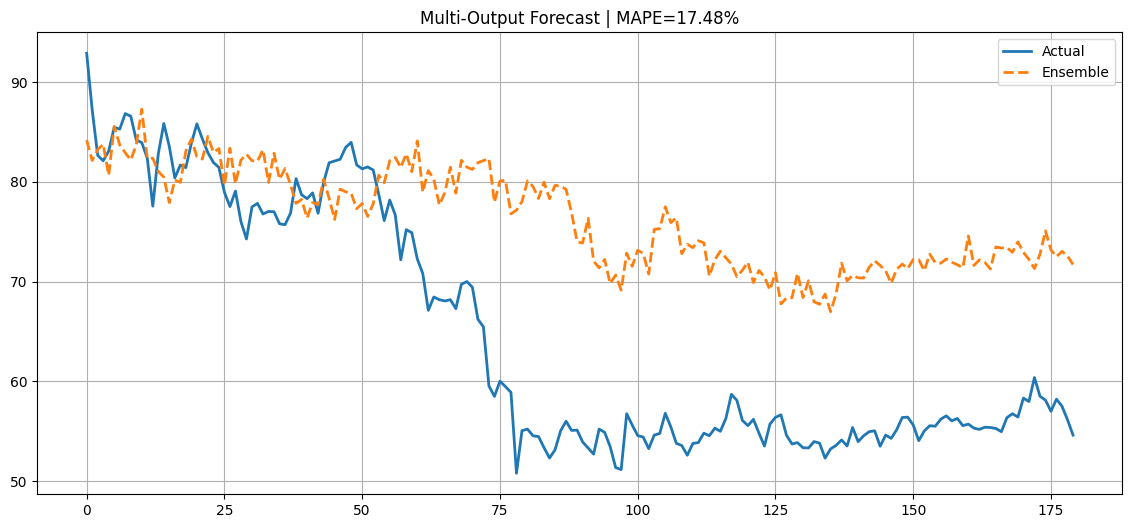

In [63]:
ltc_xgb_lstm = train_ensemble_model(
    data=ltc_5years,
    forecast_days=180,
    lags=20,
    lookback=20,
    xgb_weight=0.6,
    lstm_weight=0.4
)

Training XGBoost...
Training LSTM...

📊 RESULTS
XGB MAPE:      12.50%
LSTM MAPE:     11.86%
ENSEMBLE:      12.02%
MAE:           $9.52


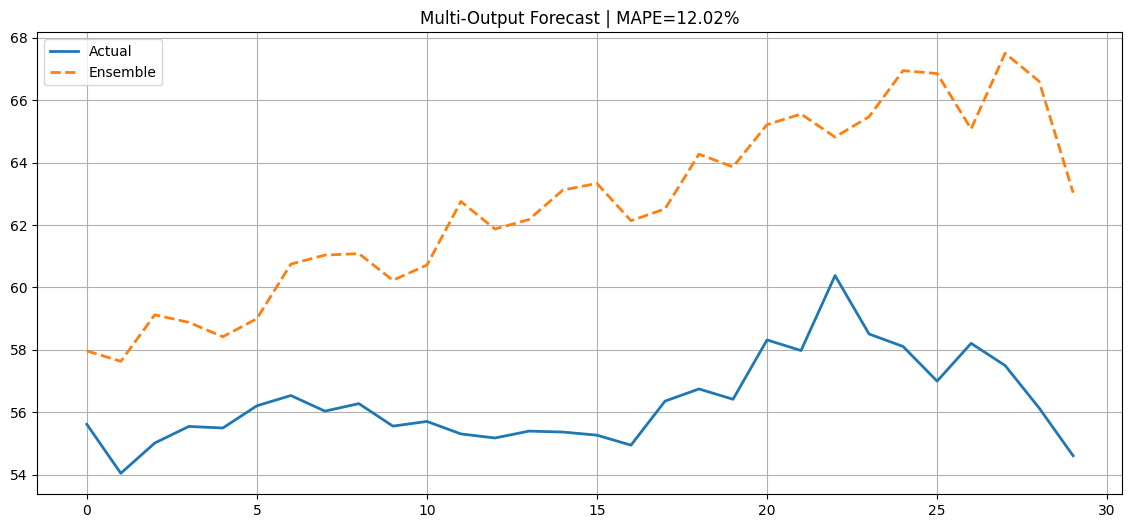

In [64]:
ltc_xgb_lstm_30 = train_ensemble_model(
    data=ltc_5years,
    forecast_days=30,
    lags=20,
    lookback=20,
    xgb_weight=0.7,
    lstm_weight=0.3
)

## XGB + TCN (WEIGHED)

In [132]:
def train_xgb_tcn_ensemble(
    data,
    forecast_days=30,
    lags=20,
    lookback=20,
    filters=64,
    kernel_size=3,
    xgb_weight=0.5,
    tcn_weight=0.5
):

    import numpy as np
    import matplotlib.pyplot as plt

    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
    from sklearn.multioutput import MultiOutputRegressor
    from xgboost import XGBRegressor
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, Dense, Dropout, GlobalAveragePooling1D, Input
    from tensorflow.keras.callbacks import EarlyStopping

    feature_cols = [c for c in data.columns if c != "close"]
    n_features = data.shape[1]

    price = data["close"].values

    # ==================================================
    # XGB DATA
    # ==================================================
    X_xgb, y_xgb = [], []

    for i in range(lags, len(data) - forecast_days):

        row = []
        row.extend(price[i-lags:i])

        for col in feature_cols:
            row.extend(data[col].values[i-lags:i])

        X_xgb.append(row)
        y_xgb.append(price[i:i+forecast_days])

    X_xgb = np.array(X_xgb)
    y_xgb = np.array(y_xgb)

    # ==================================================
    # TCN DATA
    # ==================================================
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data.values)

    X_tcn, y_tcn = [], []

    for i in range(lookback, len(scaled) - forecast_days):
        X_tcn.append(scaled[i-lookback:i])
        y_tcn.append(scaled[i:i+forecast_days, 0])

    X_tcn = np.array(X_tcn)
    y_tcn = np.array(y_tcn)

    # ==================================================
    # ALIGN
    # ==================================================
    min_len = min(len(X_xgb), len(X_tcn))

    X_xgb, y_xgb = X_xgb[-min_len:], y_xgb[-min_len:]
    X_tcn, y_tcn = X_tcn[-min_len:], y_tcn[-min_len:]

    split = int(min_len * 0.8)

    # ==================================================
    # XGB
    # ==================================================
    print("Training XGBoost...")

    xgb = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )
    )

    xgb.fit(X_xgb[:split], y_xgb[:split])

    xgb_pred = xgb.predict(X_xgb[split:])

    # ==================================================
    # TCN
    # ==================================================
    print("Training TCN...")

    tcn = Sequential([
        Input(shape=(lookback, n_features)),

        Conv1D(filters, kernel_size, activation='relu', padding='causal'),
        Dropout(0.2),

        Conv1D(filters//2, kernel_size, activation='relu', padding='causal'),
        Dropout(0.2),

        GlobalAveragePooling1D(),

        Dense(64, activation='relu'),
        Dense(forecast_days)
    ])

    tcn.compile(optimizer='adam', loss='mse')

    tcn.fit(
        X_tcn[:split],
        y_tcn[:split],
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    tcn_pred_scaled = tcn.predict(X_tcn[split:])

    # inverse TCN
    def inverse_scaled(pred):
        out = []
        for p in pred:
            dummy = np.zeros((forecast_days, n_features))
            dummy[:, 0] = p
            out.append(scaler.inverse_transform(dummy)[:, 0])
        return np.array(out)

    tcn_pred = inverse_scaled(tcn_pred_scaled)

    # ==================================================
    # ENSEMBLE
    # ==================================================
    hybrid_pred = (
        xgb_weight * xgb_pred +
        tcn_weight * tcn_pred
    )

    y_true = y_xgb[split:]

    # ==================================================
    # METRICS
    # ==================================================
    xgb_mape = mean_absolute_percentage_error(y_true.flatten(), xgb_pred.flatten()) * 100
    tcn_mape = mean_absolute_percentage_error(y_true.flatten(), tcn_pred.flatten()) * 100
    ens_mape = mean_absolute_percentage_error(y_true.flatten(), hybrid_pred.flatten()) * 100

    mae = mean_absolute_error(y_true.flatten(), hybrid_pred.flatten())

    print("\n📊 RESULTS")
    print(f"XGB MAPE: {xgb_mape:.2f}%")
    print(f"TCN MAPE: {tcn_mape:.2f}%")
    print(f"ENSEMBLE: {ens_mape:.2f}%")
    print(f"MAE: ${mae:,.2f}")

    # ==================================================
    # PLOT
    # ==================================================
    plt.figure(figsize=(14,6))

    plt.plot(y_true[-1], label="Actual")
    plt.plot(hybrid_pred[-1], label="Forecast", linestyle="--")

    plt.title("XGB + TCN Multi-Horizon")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "predictions": hybrid_pred,
        "actual": y_true,  # ИСПРАВЛЕНО: y_true вместо y_test
        "xgb_pred": xgb_pred,
        "tcn_pred": tcn_pred,
        "mape": ens_mape,
        "mae": mae,
        "models": {
            "xgb": xgb,
            "tcn": tcn,  # ИСПРАВЛЕНО: tcn вместо tcn_model
            "scaler": scaler
        },
        "metadata": {
            "lags": lags,
            "lookback": lookback,
            "forecast_days": forecast_days,
            "feature_cols": feature_cols,
            "xgb_weight": xgb_weight,
            "tcn_weight": tcn_weight
        }
    }

Training XGBoost...
Training TCN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 RESULTS
XGB MAPE: 19.31%
TCN MAPE: 19.63%
ENSEMBLE: 18.44%
MAE: $18,705.94


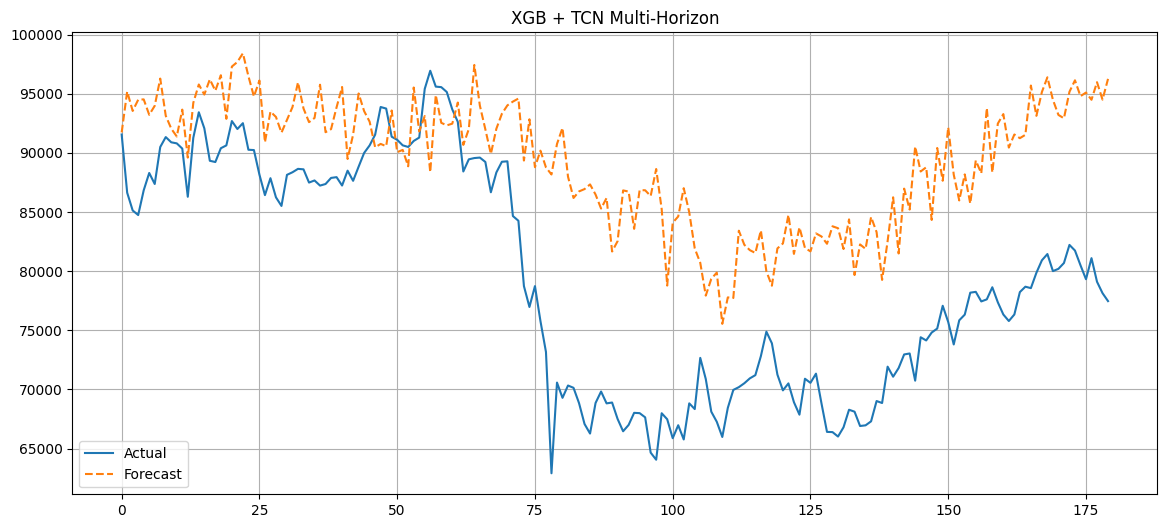

In [133]:
btc_xgb_tcn = train_xgb_tcn_ensemble(btc_5years, forecast_days=180, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

📊 RESULTS
XGB MAPE: 11.82%
TCN MAPE: 8.22%
ENSEMBLE: 9.34%
MAE: $9,167.06


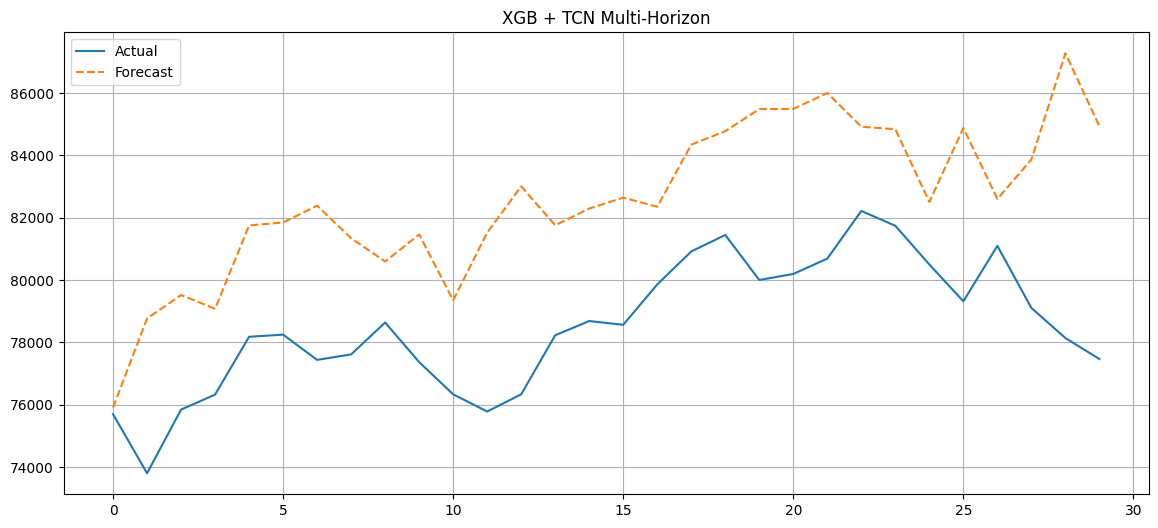

In [134]:
btc_xgb_tcn_30 = train_xgb_tcn_ensemble(btc_5years, forecast_days=30, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 RESULTS
XGB MAPE: 28.91%
TCN MAPE: 27.01%
ENSEMBLE: 27.31%
MAE: $828.05


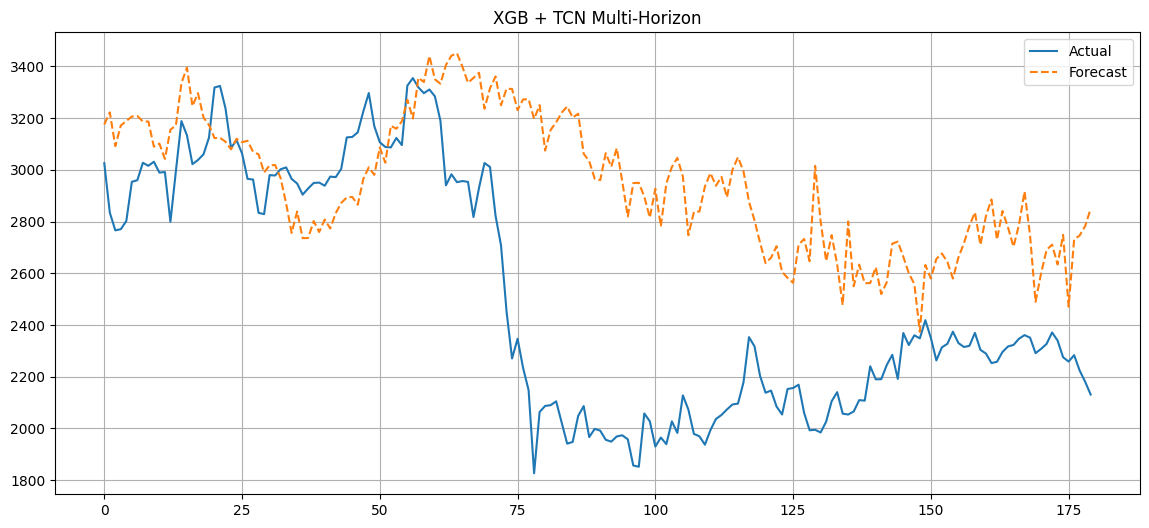

In [135]:
eth_xgb_tcn = train_xgb_tcn_ensemble(eth_5years, forecast_days=180, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

📊 RESULTS
XGB MAPE: 10.90%
TCN MAPE: 14.69%
ENSEMBLE: 11.14%
MAE: $335.34


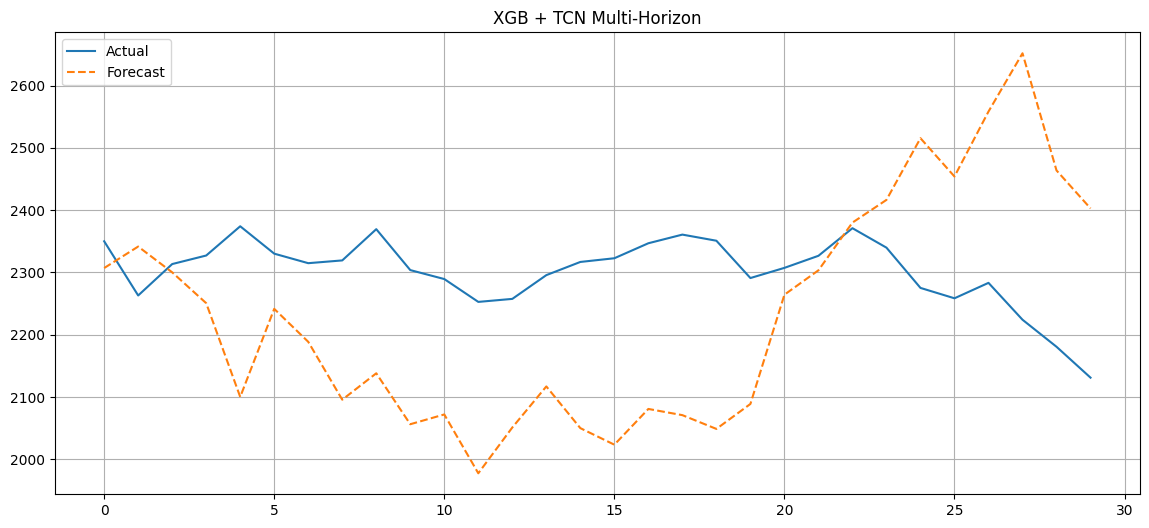

In [136]:
eth_xgb_tcn_30 = train_xgb_tcn_ensemble(eth_5years, forecast_days=30, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 RESULTS
XGB MAPE: 20.95%
TCN MAPE: 35.18%
ENSEMBLE: 21.14%
MAE: $0.53


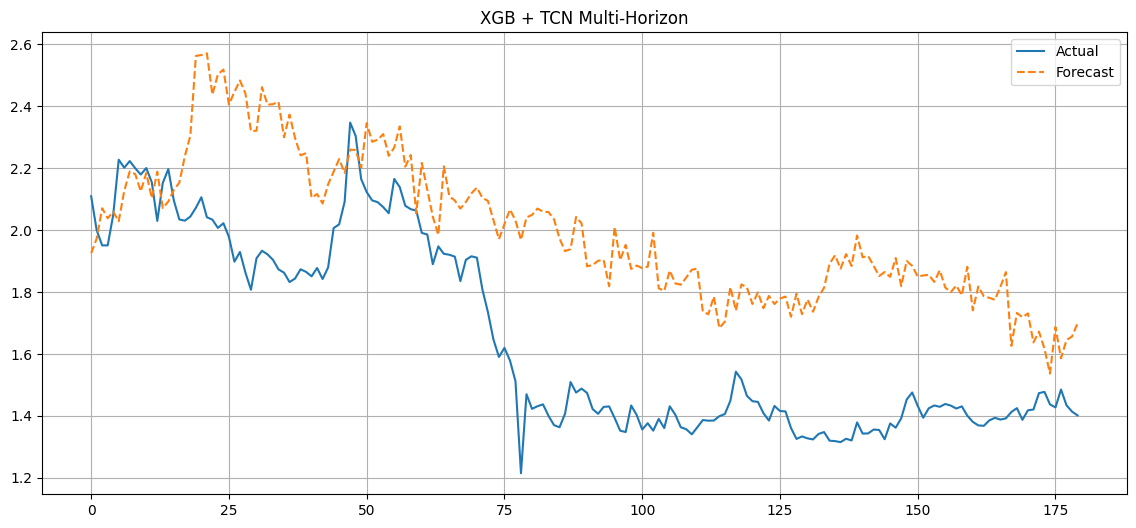

In [137]:
xrp_xgb_tcn = train_xgb_tcn_ensemble(xrp_5years, forecast_days=180, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📊 RESULTS
XGB MAPE: 22.44%
TCN MAPE: 13.08%
ENSEMBLE: 16.21%
MAE: $0.33


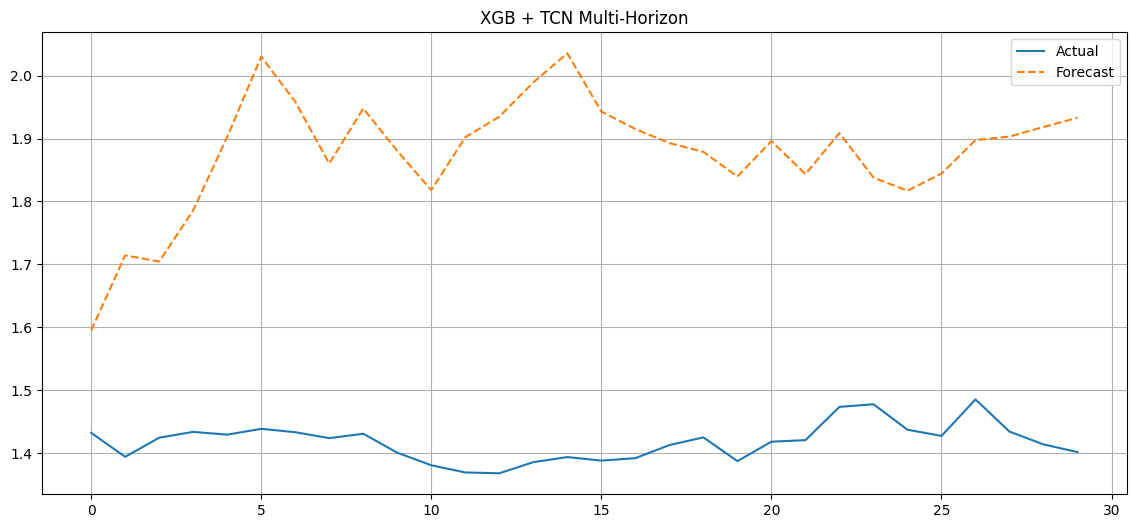

In [138]:
xrp_xgb_tcn_30 = train_xgb_tcn_ensemble(xrp_5years, forecast_days=30, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

📊 RESULTS
XGB MAPE: 18.11%
TCN MAPE: 20.67%
ENSEMBLE: 17.61%
MAE: $16.66


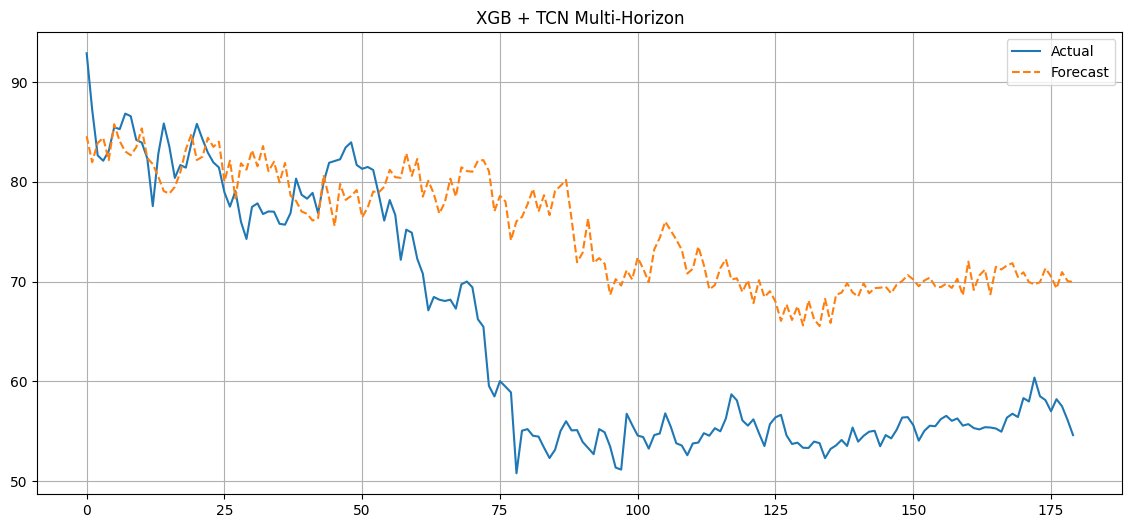

In [139]:
ltc_xgb_tcn = train_xgb_tcn_ensemble(ltc_5years, forecast_days=180, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

Training XGBoost...
Training TCN...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

📊 RESULTS
XGB MAPE: 12.50%
TCN MAPE: 13.52%
ENSEMBLE: 12.51%
MAE: $9.88


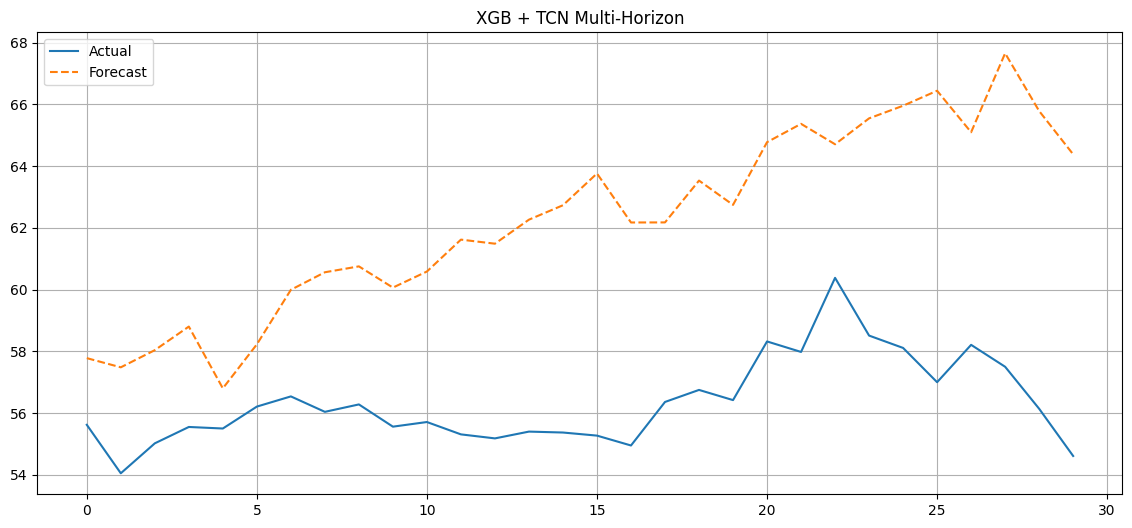

In [140]:
ltc_xgb_tcn_30 = train_xgb_tcn_ensemble(ltc_5years, forecast_days=30, lags = 20, lookback = 20, xgb_weight= 0.6, tcn_weight=0.4)

## TCN + LSTM (WEIGHED)

In [141]:
def train_tcn_lstm_ensemble(
    data,
    forecast_days=30,
    lookback=20,
    tcn_filters=64,
    tcn_kernel=3,
    lstm_units=64,
    tcn_weight=0.5,
    lstm_weight=0.5
):

    import numpy as np
    import matplotlib.pyplot as plt

    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, GlobalAveragePooling1D, Input
    from tensorflow.keras.callbacks import EarlyStopping

    feature_cols = [c for c in data.columns if c != "close"]
    n_features = data.shape[1]

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data.values)

    X, y = [], []

    for i in range(lookback, len(scaled) - forecast_days):
        X.append(scaled[i-lookback:i])
        y.append(scaled[i:i+forecast_days, 0])

    X = np.array(X)
    y = np.array(y)

    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test_scaled = y[:split], y[split:]

    # inverse actual
    def inverse(y_scaled):
        out = []
        for p in y_scaled:
            dummy = np.zeros((forecast_days, n_features))
            dummy[:, 0] = p
            out.append(scaler.inverse_transform(dummy)[:, 0])
        return np.array(out)

    y_test = inverse(y_test_scaled)

    # ==================================================
    # TCN
    # ==================================================
    print("Training TCN...")

    tcn = Sequential([
        Input(shape=(lookback, n_features)),

        Conv1D(tcn_filters, tcn_kernel, activation='relu', padding='causal'),
        Dropout(0.2),

        Conv1D(tcn_filters//2, tcn_kernel, activation='relu', padding='causal'),
        Dropout(0.2),

        GlobalAveragePooling1D(),

        Dense(64, activation='relu'),
        Dense(forecast_days)
    ])

    tcn.compile(optimizer='adam', loss='mse')

    tcn.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    # ==================================================
    # LSTM
    # ==================================================
    print("Training LSTM...")

    lstm = Sequential([
        Input(shape=(lookback, n_features)),

        LSTM(lstm_units, return_sequences=True),
        Dropout(0.2),

        LSTM(32),
        Dropout(0.2),

        Dense(64, activation='relu'),
        Dense(forecast_days)
    ])

    lstm.compile(optimizer='adam', loss='mse')

    lstm.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )

    # ==================================================
    # PREDICT
    # ==================================================
    tcn_pred_scaled = tcn.predict(X_test)
    lstm_pred_scaled = lstm.predict(X_test)

    tcn_pred = inverse(tcn_pred_scaled)
    lstm_pred = inverse(lstm_pred_scaled)

    ensemble = tcn_weight * tcn_pred + lstm_weight * lstm_pred

    # ==================================================
    # METRICS
    # ==================================================
    tcn_mape = mean_absolute_percentage_error(y_test.flatten(), tcn_pred.flatten()) * 100
    lstm_mape = mean_absolute_percentage_error(y_test.flatten(), lstm_pred.flatten()) * 100
    ens_mape = mean_absolute_percentage_error(y_test.flatten(), ensemble.flatten()) * 100

    mae = mean_absolute_error(y_test.flatten(), ensemble.flatten())

    print("\n📊 RESULTS")
    print(f"TCN MAPE: {tcn_mape:.2f}%")
    print(f"LSTM MAPE: {lstm_mape:.2f}%")
    print(f"ENSEMBLE: {ens_mape:.2f}%")
    print(f"MAE: ${mae:,.2f}")

    # ==================================================
    # PLOT
    # ==================================================
    plt.figure(figsize=(14,6))

    plt.plot(y_test[-1], label="Actual")
    plt.plot(ensemble[-1], label="Forecast", linestyle="--")

    plt.title("TCN + LSTM Multi-Horizon")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "predictions": ensemble,
        "actual": y_test,
        "tcn_pred": tcn_pred,  # ДОБАВЛЕНО
        "lstm_pred": lstm_pred,  # ДОБАВЛЕНО
        "mape": ens_mape,  # ДОБАВЛЕНО
        "mae": mae,  # ДОБАВЛЕНО
        "models": {  # ДОБАВЛЕНО для консистентности
            "tcn": tcn,
            "lstm": lstm,
            "scaler": scaler
        },
        "metadata": {
            "lookback": lookback,
            "forecast_days": forecast_days,
            "feature_cols": feature_cols,
            "tcn_filters": tcn_filters,  # ДОБАВЛЕНО
            "tcn_kernel": tcn_kernel,  # ДОБАВЛЕНО
            "lstm_units": lstm_units,  # ДОБАВЛЕНО
            "tcn_weight": tcn_weight,  # ДОБАВЛЕНО
            "lstm_weight": lstm_weight  # ДОБАВЛЕНО
        }
    }

Training TCN...
Training LSTM...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

📊 RESULTS
TCN MAPE: 18.28%
LSTM MAPE: 18.79%
ENSEMBLE: 17.85%
MAE: $17,793.39


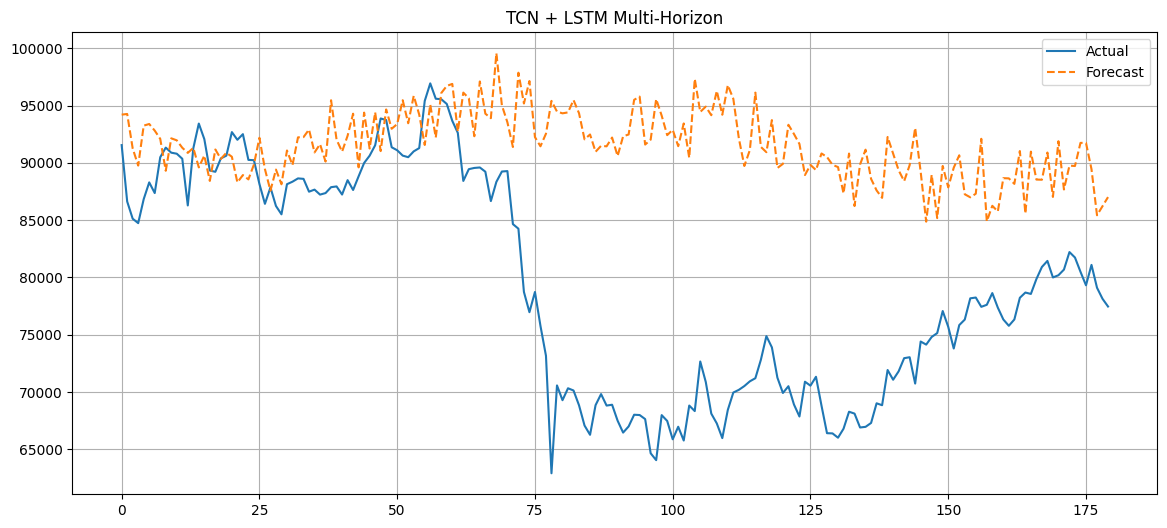

In [142]:
btc_tcn_lstm = train_tcn_lstm_ensemble(btc_5years, forecast_days=180, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

Training TCN...
Training LSTM...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

📊 RESULTS
TCN MAPE: 10.84%
LSTM MAPE: 23.39%
ENSEMBLE: 16.62%
MAE: $17,271.70


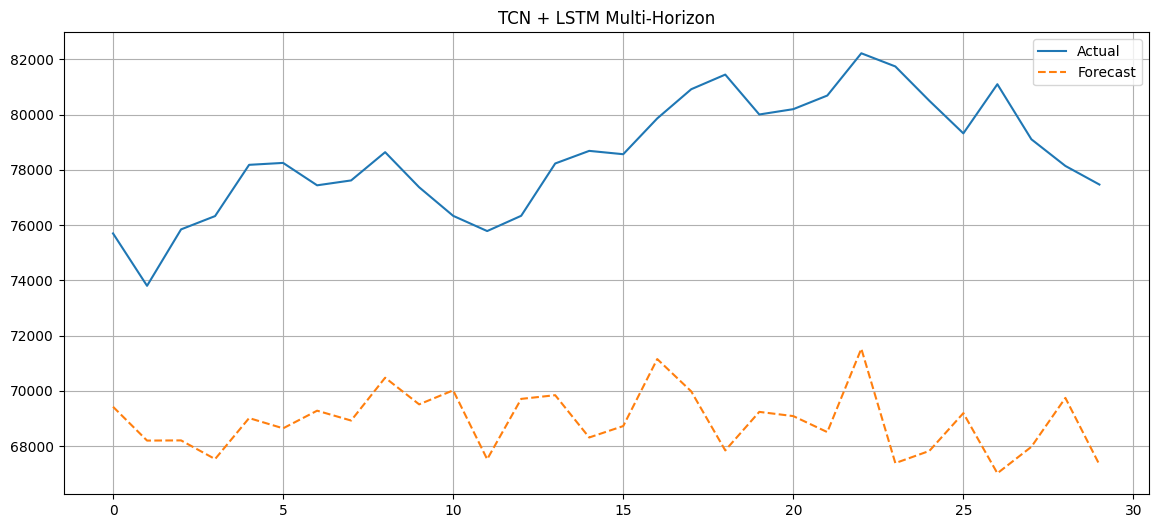

In [143]:
btc_tcn_lstm_30 = train_tcn_lstm_ensemble(btc_5years, forecast_days=30, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

Training TCN...
Training LSTM...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

📊 RESULTS
TCN MAPE: 25.81%
LSTM MAPE: 25.63%
ENSEMBLE: 24.98%
MAE: $814.81


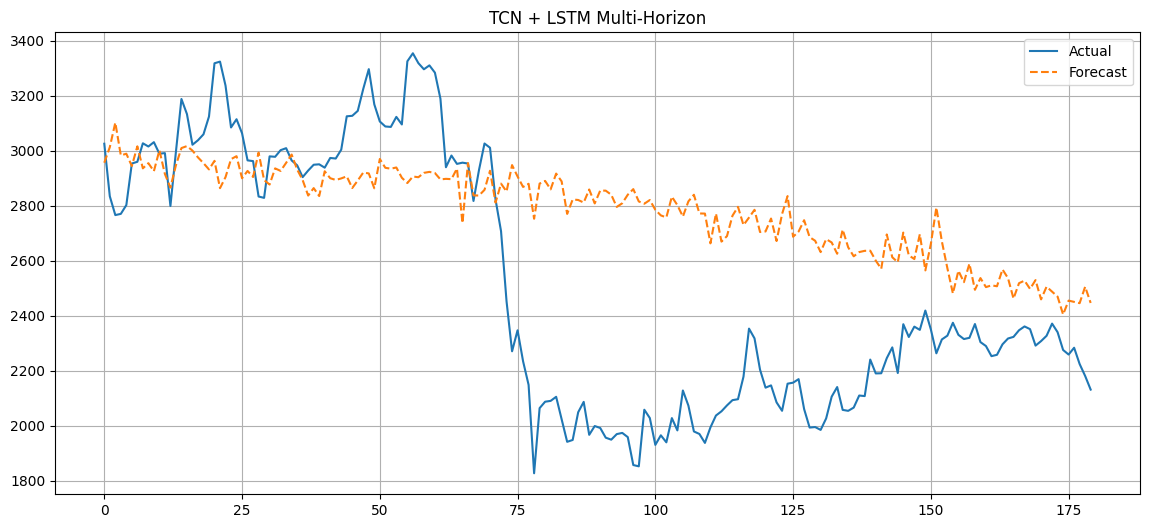

In [144]:
eth_tcn_lstm = train_tcn_lstm_ensemble(eth_5years, forecast_days=180, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

Training TCN...
Training LSTM...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

📊 RESULTS
TCN MAPE: 14.66%
LSTM MAPE: 13.59%
ENSEMBLE: 12.75%
MAE: $392.32


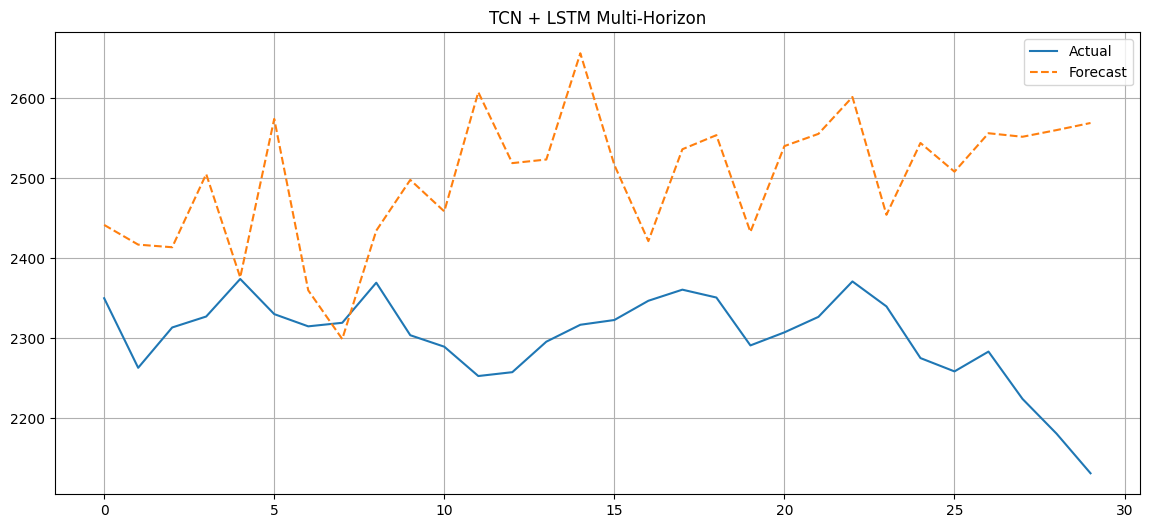

In [145]:
eth_tcn_lstm_30 = train_tcn_lstm_ensemble(eth_5years, forecast_days=30, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

Training TCN...
Training LSTM...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

📊 RESULTS
TCN MAPE: 29.80%
LSTM MAPE: 34.80%
ENSEMBLE: 32.58%
MAE: $0.84


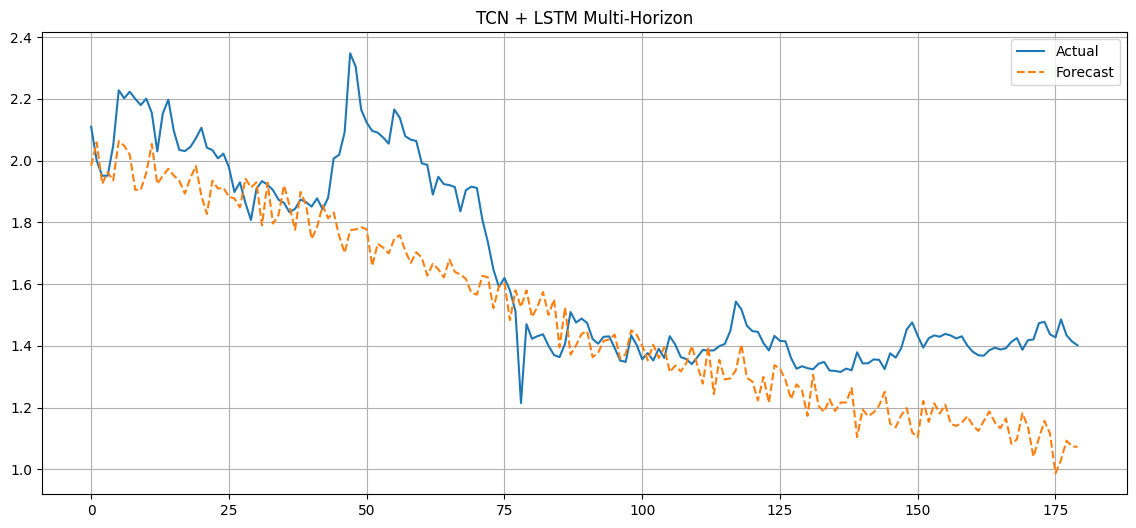

In [146]:
xrp_tcn_lstm = train_tcn_lstm_ensemble(xrp_5years, forecast_days=180, lookback=40, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.3, lstm_weight=0.7)

Training TCN...
Training LSTM...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

📊 RESULTS
TCN MAPE: 12.33%
LSTM MAPE: 10.98%
ENSEMBLE: 10.39%
MAE: $0.23


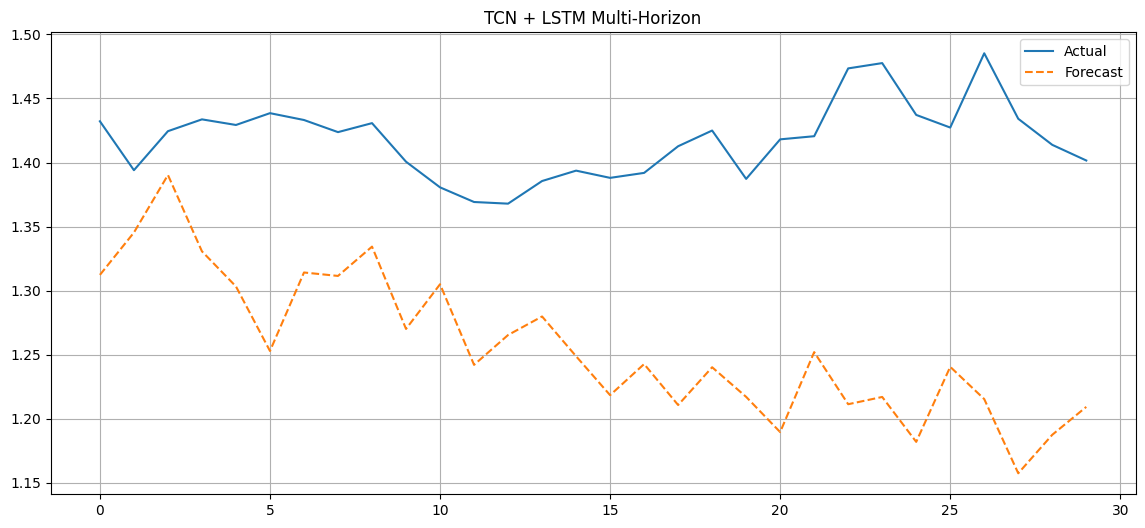

In [147]:
xrp_tcn_lstm_30 = train_tcn_lstm_ensemble(xrp_5years, forecast_days=30, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

Training TCN...
Training LSTM...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

📊 RESULTS
TCN MAPE: 20.69%
LSTM MAPE: 19.42%
ENSEMBLE: 19.95%
MAE: $18.93


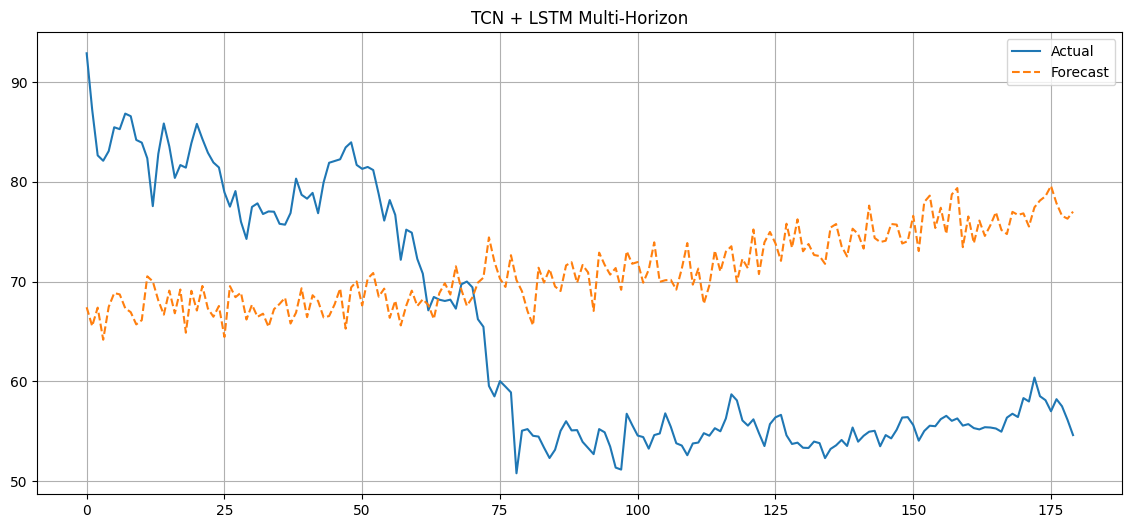

In [148]:
ltc_tcn_lstm = train_tcn_lstm_ensemble(ltc_5years, forecast_days=180, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

Training TCN...
Training LSTM...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

📊 RESULTS
TCN MAPE: 14.05%
LSTM MAPE: 12.67%
ENSEMBLE: 13.28%
MAE: $10.47


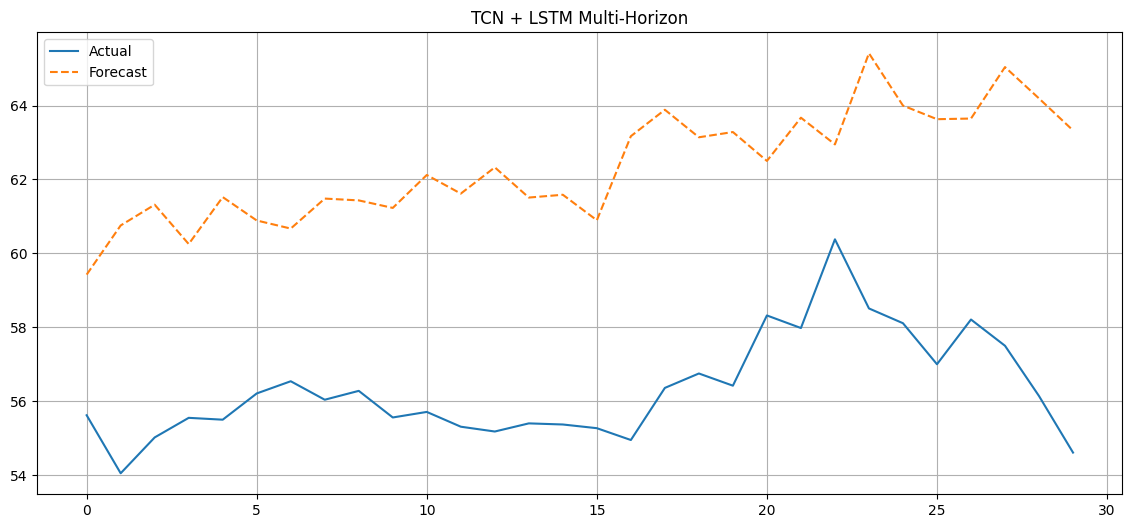

In [149]:
ltc_tcn_lstm_30 = train_tcn_lstm_ensemble(ltc_5years, forecast_days=30, lookback=20, tcn_filters=64, tcn_kernel=3, lstm_units=64, tcn_weight=0.5, lstm_weight=0.5)

In [150]:
import os
import json
import pickle

from datetime import datetime


def save_ensemble_model(
    model_result,
    symbol,
    model_type,
    horizon=180
):

    # ==================================================
    # BASE DIR
    # ==================================================

    PROJECT_ROOT = os.getcwd()

    MODELS_DIR = os.path.join(
        PROJECT_ROOT,
        "models"
    )

    os.makedirs(MODELS_DIR, exist_ok=True)

    # ==================================================
    # MODEL NAME
    # ==================================================

    model_name = (
        f"{symbol.lower()}_{model_type}_{horizon}"
    )

    model_dir = os.path.normpath(
        os.path.join(
            MODELS_DIR,
            model_name
        )
    )

    os.makedirs(model_dir, exist_ok=True)

    # ==================================================
    # MODELS
    # ==================================================

    models = model_result["models"]

    # ---------------- XGBOOST ----------------

    if "xgb" in models:

        xgb_path = os.path.join(
            model_dir,
            "xgb_model.pkl"
        )

        with open(xgb_path, "wb") as f:

            pickle.dump(
                models["xgb"],
                f
            )

    # ---------------- LSTM ----------------

    if "lstm" in models:

        lstm_path = os.path.join(
            model_dir,
            "lstm_model.keras"
        )

        models["lstm"].save(
            lstm_path
        )

    else:

        lstm_path = None

    # ---------------- TCN ----------------

    if "tcn" in models:

        tcn_path = os.path.join(
            model_dir,
            "tcn_model.keras"
        )

        models["tcn"].save(
            tcn_path
        )

    else:

        tcn_path = None

    # ---------------- SCALER ----------------

    if "scaler" in models:

        scaler_path = os.path.join(
            model_dir,
            "scaler.pkl"
        )

        with open(scaler_path, "wb") as f:

            pickle.dump(
                models["scaler"],
                f
            )

    else:

        scaler_path = None

    # ==================================================
    # METADATA
    # ==================================================

    metadata = {

        # ==========================================
        # BASIC INFO
        # ==========================================

        "symbol": symbol.upper(),

        "model_name": model_name,

        "model_type": model_type,

        "horizon": horizon,

        # ==========================================
        # PATHS
        # ==========================================

        "model_path": model_dir,

        "scaler_path": scaler_path,

        "xgb_path": xgb_path if "xgb" in models else None,

        "lstm_path": lstm_path,

        "tcn_path": tcn_path,

        # ==========================================
        # MODEL PARAMS
        # ==========================================

        "lags": model_result["metadata"].get(
            "lags"
        ),

        "lookback": model_result["metadata"][
            "lookback"
        ],

        "feature_cols": model_result["metadata"][
            "feature_cols"
        ],

        # ==========================================
        # ENSEMBLE WEIGHTS
        # ==========================================

        "xgb_weight": model_result["metadata"].get(
            "xgb_weight"
        ),

        "lstm_weight": model_result["metadata"].get(
            "lstm_weight"
        ),

        "tcn_weight": model_result["metadata"].get(
            "tcn_weight"
        ),

        # ==========================================
        # METRICS
        # ==========================================

        "test_mape": float(
            model_result["mape"]
        ),

        "test_mae": float(
            model_result["mae"]
        ),

        "n_samples": int(
            len(model_result["actual"])
        ),

        # ==========================================
        # SYSTEM INFO
        # ==========================================

        "created_at": str(datetime.utcnow()),

        "is_active": 1
    }

    # ==================================================
    # SAVE JSON
    # ==================================================

    metadata_path = os.path.join(
        model_dir,
        "metadata.json"
    )

    with open(metadata_path, "w") as f:

        json.dump(
            metadata,
            f,
            indent=4
        )

    print("=" * 60)
    print("✅ MODEL SAVED")
    print("MODEL:", model_name)
    print("PATH:", model_dir)
    print("=" * 60)

    return model_dir

In [157]:
save_ensemble_model(btc_xgb_lstm, "BTC", "xgb-lstm", 180)
save_ensemble_model(eth_xgb_tcn, "ETH", "xgb-tcn", 180)
save_ensemble_model(xrp_tcn_lstm, "XRP", "tcn-lstm", 180)
save_ensemble_model(ltc_xgb_lstm, "LTC", "xgb-lstm", 180)
save_ensemble_model(btc_xgb_tcn_30, "BTC", "xgb-tcn", 30)
save_ensemble_model(eth_xgb_tcn_30, "ETH", "xgb-tcn", 30)
save_ensemble_model(xrp_xgb_lstm_30, "XRP", "xgb-lstm", 30)
save_ensemble_model(ltc_xgb_lstm_30, "LTC", "xgb-lstm", 30)

C:\r2\ipykernel_17528\2916066537.py:205: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": str(datetime.utcnow()),


✅ MODEL SAVED
MODEL: btc_xgb-lstm_180
PATH: d:\forecast_service\models\btc_xgb-lstm_180
✅ MODEL SAVED
MODEL: eth_xgb-tcn_180
PATH: d:\forecast_service\models\eth_xgb-tcn_180
✅ MODEL SAVED
MODEL: xrp_tcn-lstm_180
PATH: d:\forecast_service\models\xrp_tcn-lstm_180
✅ MODEL SAVED
MODEL: ltc_xgb-lstm_180
PATH: d:\forecast_service\models\ltc_xgb-lstm_180
✅ MODEL SAVED
MODEL: btc_xgb-tcn_30
PATH: d:\forecast_service\models\btc_xgb-tcn_30
✅ MODEL SAVED
MODEL: eth_xgb-tcn_30
PATH: d:\forecast_service\models\eth_xgb-tcn_30
✅ MODEL SAVED
MODEL: xrp_xgb-lstm_30
PATH: d:\forecast_service\models\xrp_xgb-lstm_30
✅ MODEL SAVED
MODEL: ltc_xgb-lstm_30
PATH: d:\forecast_service\models\ltc_xgb-lstm_30


'd:\\forecast_service\\models\\ltc_xgb-lstm_30'

Loading data...
✓ Data loaded


🔮 РЕАЛЬНЫЙ ПРОГНОЗ: BTC - 30 days (xgb-tcn)
  ✓ Loaded XGBoost model
  ✓ Loaded TCN model
  ✓ Loaded Scaler

  📋 МЕТАДАННЫЕ МОДЕЛИ:
     Symbol: BTC
     Type: xgb-tcn
     Horizon: 30 days
     Lookback: 20 days
     Test MAPE: 9.33804278682966%

  📊 Прогноз на 30 дней вперед
  📈 Используем последние 20 дней данных
  🔧 Компоненты ансамбля: XGB + TCN
  ✅ XGBoost: прогноз готов
  ✅ TCN: прогноз готов
  🔗 XGB вес: 0.6
  🔗 TCN вес: 0.4

  📊 ДЕТАЛИ ПРОГНОЗА:
  💰 Текущая цена: $77,008.90
  📈 Прогноз на день 1: $81,990.27
  🎯 Прогноз на день 30: $94,809.09
  📉 Ожидаемое изменение: +17,800.19 (+23.1%)
  ⬆️ Максимум: $94,809.09 (день 30)
  ⬇️ Минимум: $81,707.31 (день 2)

🔮 РЕАЛЬНЫЙ ПРОГНОЗ: BTC - 180 days (xgb-lstm)
  ✓ Loaded XGBoost model
  ✓ Loaded LSTM model
  ✓ Loaded Scaler

  📋 МЕТАДАННЫЕ МОДЕЛИ:
     Symbol: BTC
     Type: xgb-lstm
     Horizon: 180 days
     Lookback: 20 days
     Test MAPE: 18.031333492963324%

  📊 Прогноз на 180 дней вперед
  📈 Испол

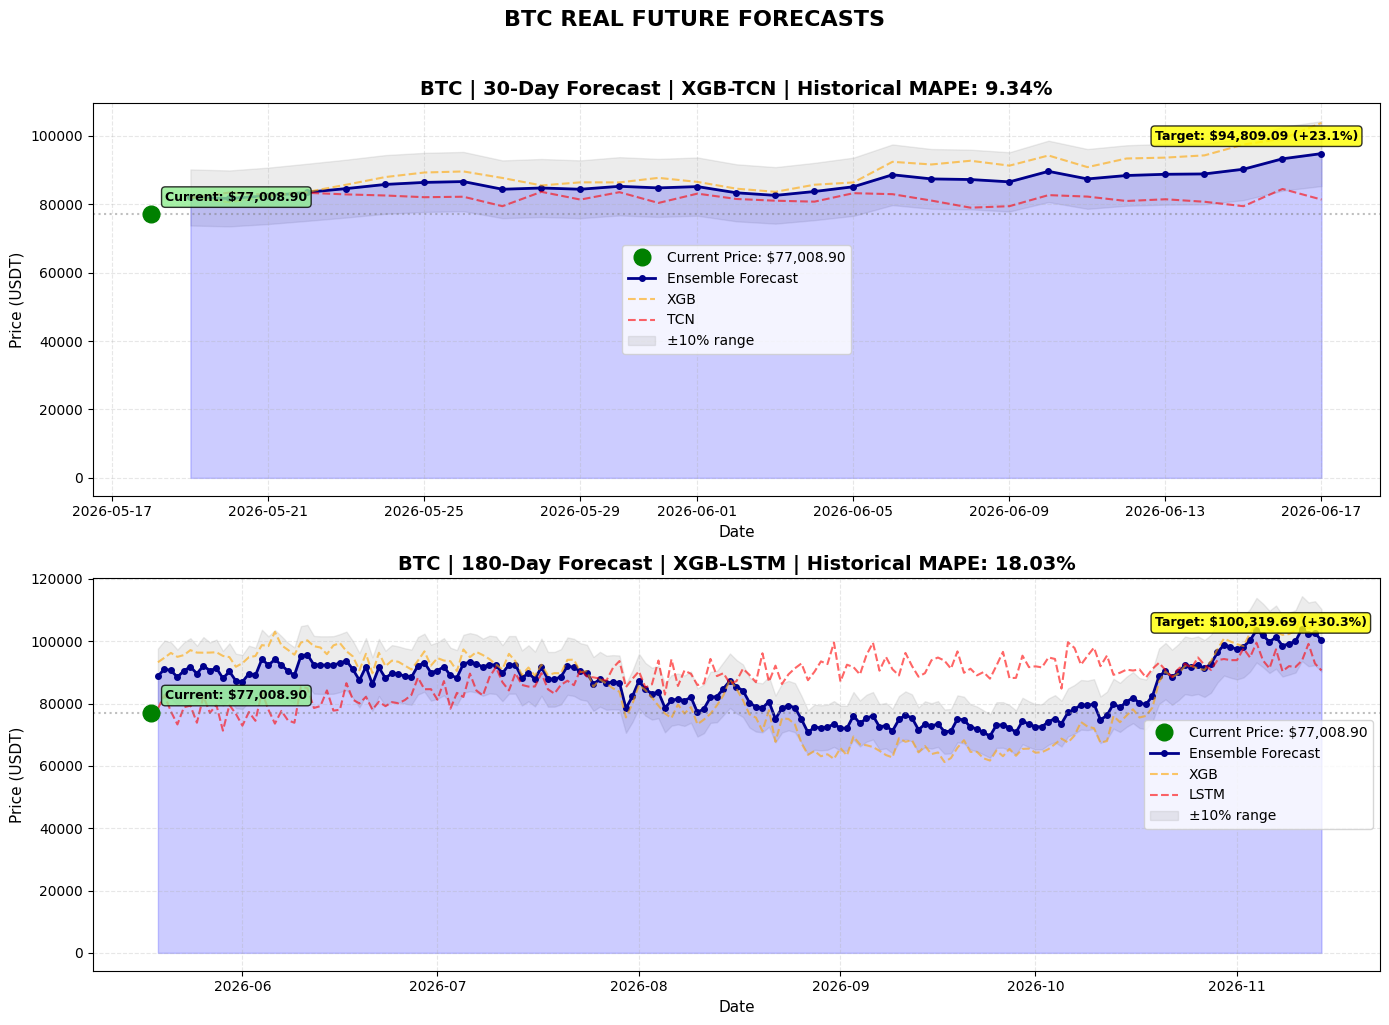

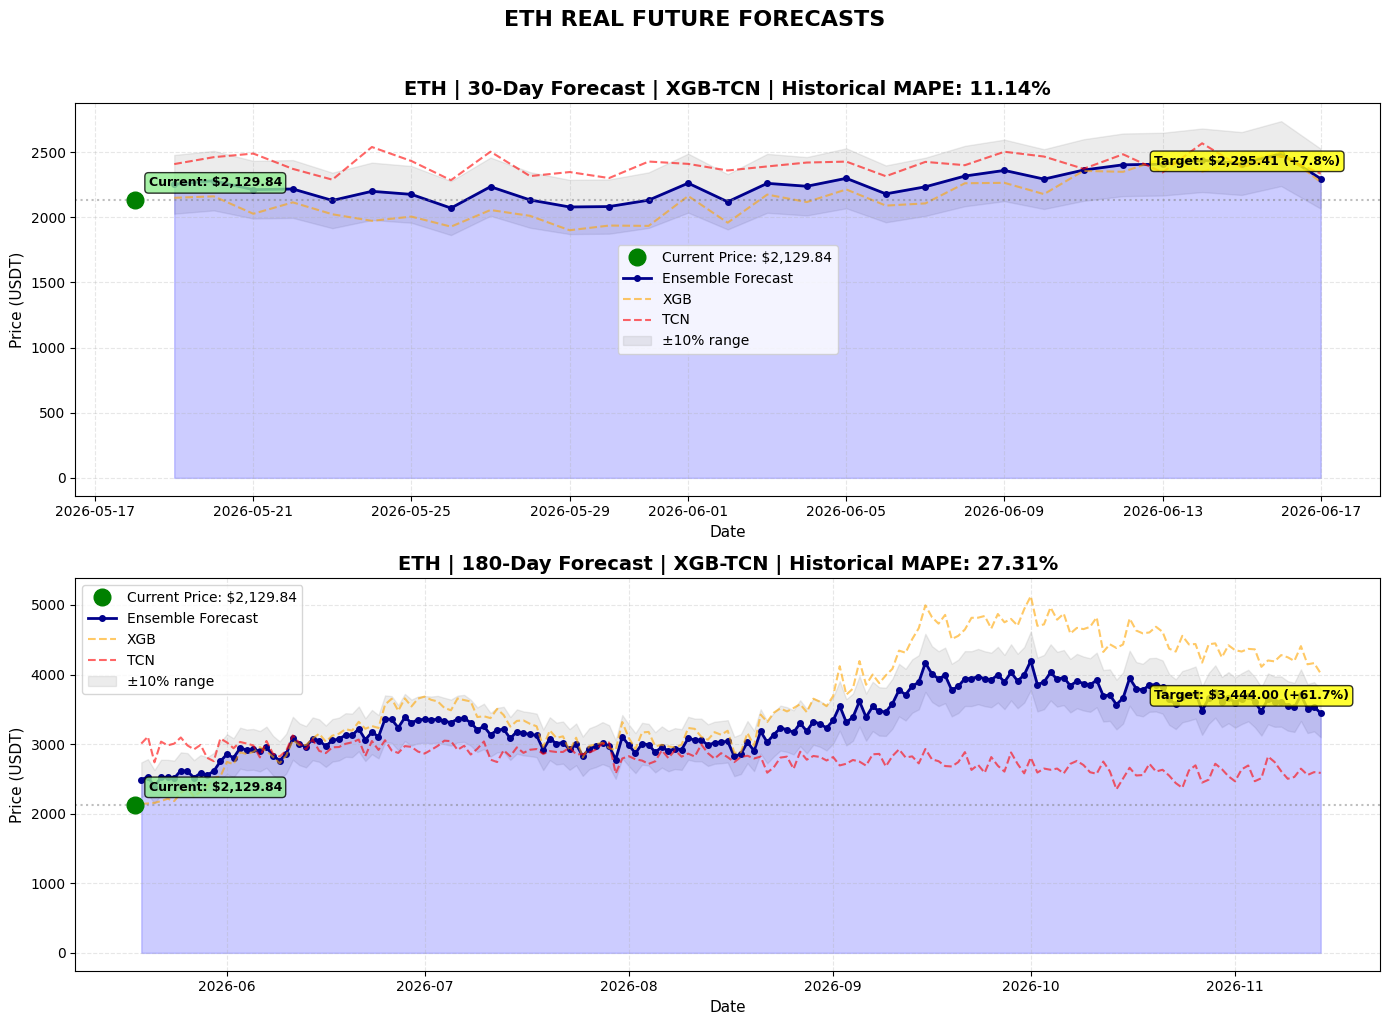

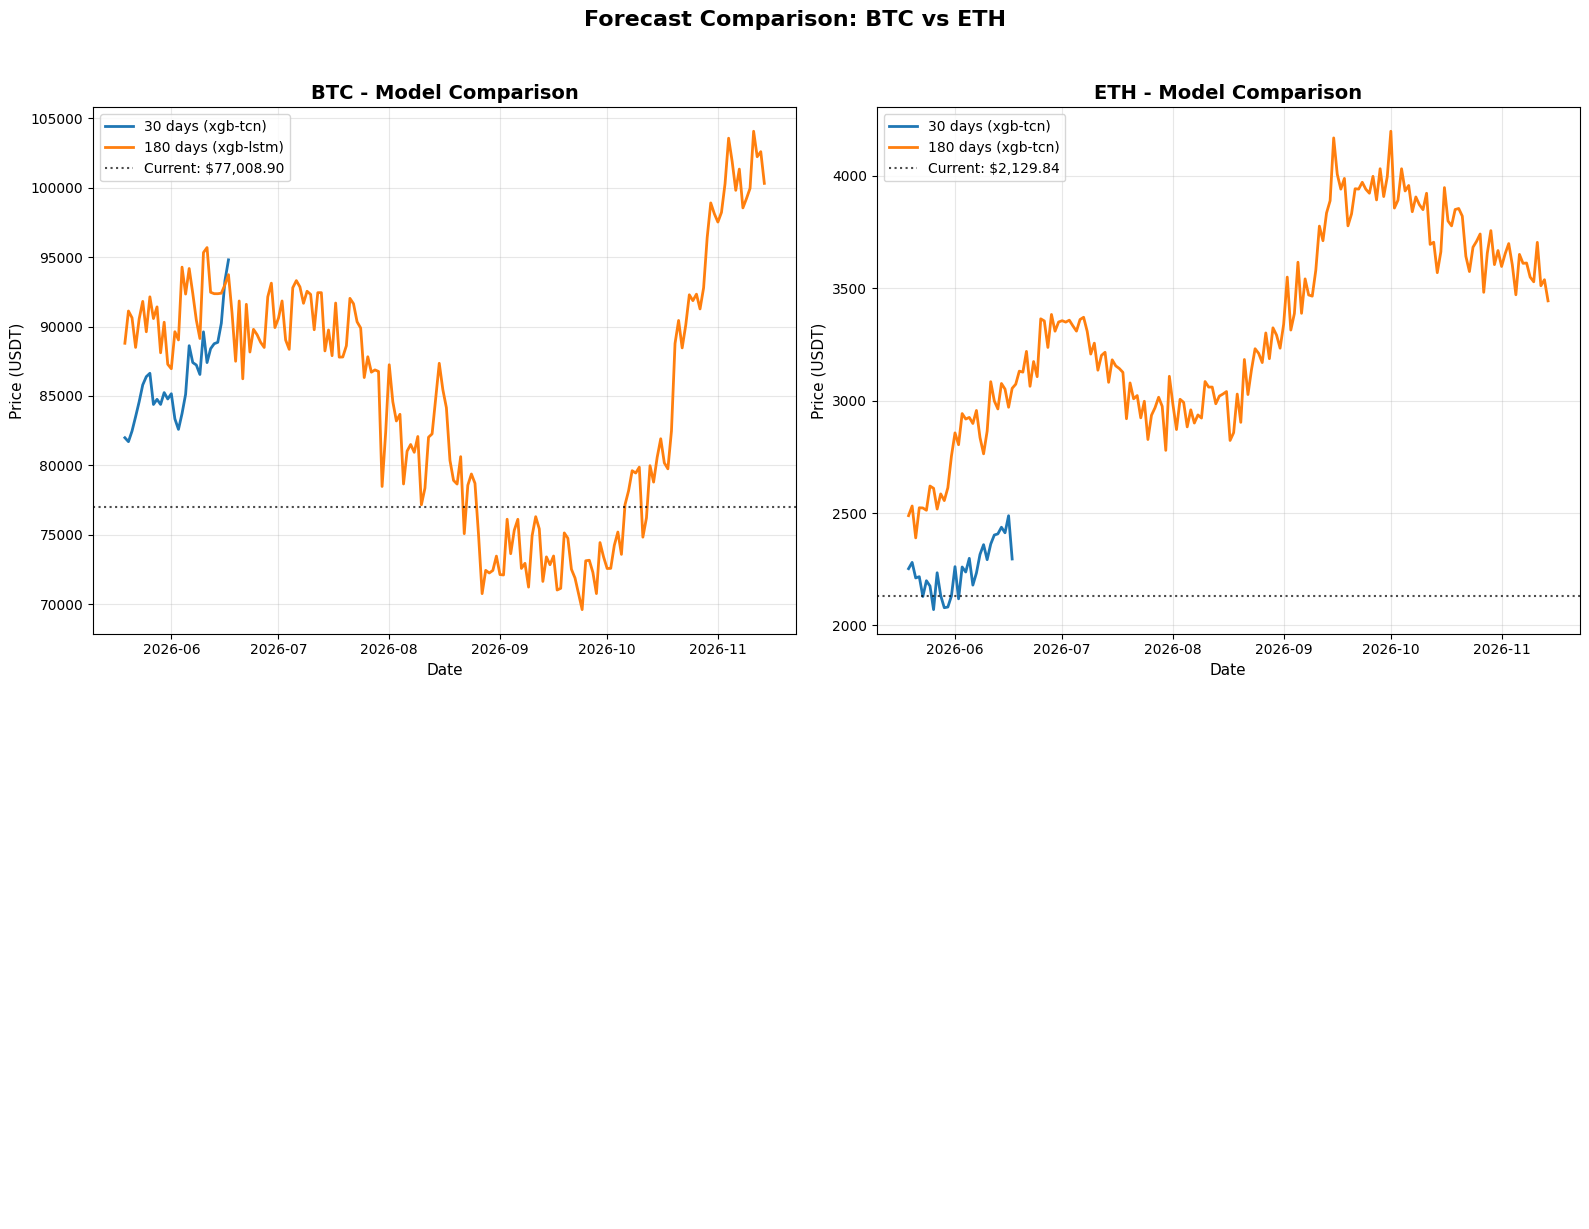


💾 Сохранено: FUTURE_BTC_30_xgb-tcn.csv

💾 Сохранено: FUTURE_BTC_180_xgb-lstm.csv

💾 Сохранено: FUTURE_ETH_30_xgb-tcn.csv

💾 Сохранено: FUTURE_ETH_180_xgb-tcn.csv

✅ ВСЕ ПРОГНОЗЫ И ГРАФИКИ ГОТОВЫ!


In [162]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def load_ensemble_model(symbol, model_type, horizon=180):
    """
    Загружает сохраненную ансамблевую модель
    """
    
    PROJECT_ROOT = os.getcwd()
    MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
    
    model_name = f"{symbol.lower()}_{model_type}_{horizon}"
    model_dir = os.path.join(MODELS_DIR, model_name)
    
    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Model not found: {model_dir}")
    
    # Загрузка метаданных
    metadata_path = os.path.join(model_dir, "metadata.json")
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    
    # Приводим ключи к единому формату
    if 'forecast_days' not in metadata and 'horizon' in metadata:
        metadata['forecast_days'] = metadata['horizon']
    elif 'forecast_days' not in metadata and 'horizon' not in metadata:
        metadata['forecast_days'] = horizon
    
    if 'lookback' not in metadata:
        metadata['lookback'] = metadata.get('lags', 20)
    
    models = {}
    
    # Загрузка XGBoost
    xgb_path = metadata.get("xgb_path")
    if xgb_path and os.path.exists(xgb_path):
        with open(xgb_path, "rb") as f:
            models["xgb"] = pickle.load(f)
        print(f"  ✓ Loaded XGBoost model")
    
    # Загрузка LSTM
    lstm_path = metadata.get("lstm_path")
    if lstm_path and os.path.exists(lstm_path):
        models["lstm"] = load_model(lstm_path)
        print(f"  ✓ Loaded LSTM model")
    
    # Загрузка TCN
    tcn_path = metadata.get("tcn_path")
    if tcn_path and os.path.exists(tcn_path):
        models["tcn"] = load_model(tcn_path)
        print(f"  ✓ Loaded TCN model")
    
    # Загрузка Scaler
    scaler_path = metadata.get("scaler_path")
    if scaler_path and os.path.exists(scaler_path):
        with open(scaler_path, "rb") as f:
            models["scaler"] = pickle.load(f)
        print(f"  ✓ Loaded Scaler")
    
    print(f"\n  📋 МЕТАДАННЫЕ МОДЕЛИ:")
    print(f"     Symbol: {metadata.get('symbol', symbol)}")
    print(f"     Type: {metadata.get('model_type', model_type)}")
    print(f"     Horizon: {metadata.get('forecast_days', horizon)} days")
    print(f"     Lookback: {metadata.get('lookback', 'N/A')} days")
    print(f"     Test MAPE: {metadata.get('test_mape', 'N/A')}%")
    
    return {
        "models": models,
        "metadata": metadata,
        "model_dir": model_dir
    }


def predict_ensemble_future(loaded_model, data):
    """
    Делает РЕАЛЬНЫЙ прогноз в будущее
    """
    
    models = loaded_model["models"]
    metadata = loaded_model["metadata"]
    
    # Получаем параметры
    forecast_days = metadata.get("forecast_days") or metadata.get("horizon")
    if forecast_days is None:
        raise ValueError("Neither 'forecast_days' nor 'horizon' found in metadata")
    
    lookback = metadata.get("lookback")
    if lookback is None:
        raise ValueError("'lookback' not found in metadata")
    
    feature_cols = metadata.get("feature_cols", [])
    
    # Получаем веса
    xgb_weight = metadata.get("xgb_weight", 0.5)
    lstm_weight = metadata.get("lstm_weight", 0.5)
    tcn_weight = metadata.get("tcn_weight", 0.5)
    
    # Историческая точность
    historical_mape = metadata.get("test_mape", None)
    
    # Подготовка данных
    price = data["close"].values
    
    # Определяем тип модели
    has_xgb = "xgb" in models
    has_lstm = "lstm" in models
    has_tcn = "tcn" in models
    
    print(f"\n  📊 Прогноз на {forecast_days} дней вперед")
    print(f"  📈 Используем последние {lookback} дней данных")
    print(f"  🔧 Компоненты ансамбля: ", end="")
    components = []
    if has_xgb: components.append("XGB")
    if has_lstm: components.append("LSTM") 
    if has_tcn: components.append("TCN")
    print(" + ".join(components))
    
    # ==================================================
    # XGBOOST
    # ==================================================
    xgb_pred = None
    if has_xgb:
        lags = metadata.get("lags", lookback)
        
        if len(price) < lags:
            raise ValueError(f"Not enough data: need {lags} days, have {len(price)}")
        
        X_xgb = []
        row = []
        row.extend(price[-lags:])
        
        for col in feature_cols:
            if col in data.columns:
                row.extend(data[col].values[-lags:])
        
        X_xgb.append(row)
        X_xgb = np.array(X_xgb)
        
        xgb_pred = models["xgb"].predict(X_xgb)
        print(f"  ✅ XGBoost: прогноз готов")
    
    # ==================================================
    # LSTM
    # ==================================================
    lstm_pred = None
    if has_lstm and "scaler" in models:
        scaler = models["scaler"]
        n_features = data.shape[1]
        
        last_data = data.values[-lookback:]
        scaled_data = scaler.transform(last_data)
        X_lstm = scaled_data.reshape(1, lookback, n_features)
        
        lstm_scaled = models["lstm"].predict(X_lstm, verbose=0)
        
        lstm_pred = []
        for pred in lstm_scaled:
            dummy = np.zeros((forecast_days, n_features))
            dummy[:, 0] = pred
            restored = scaler.inverse_transform(dummy)[:, 0]
            lstm_pred.append(restored)
        
        lstm_pred = np.array(lstm_pred)
        print(f"  ✅ LSTM: прогноз готов")
    
    # ==================================================
    # TCN
    # ==================================================
    tcn_pred = None
    if has_tcn and "scaler" in models:
        scaler = models["scaler"]
        n_features = data.shape[1]
        
        last_data = data.values[-lookback:]
        scaled_data = scaler.transform(last_data)
        X_tcn = scaled_data.reshape(1, lookback, n_features)
        
        tcn_scaled = models["tcn"].predict(X_tcn, verbose=0)
        
        tcn_pred = []
        for pred in tcn_scaled:
            dummy = np.zeros((forecast_days, n_features))
            dummy[:, 0] = pred
            restored = scaler.inverse_transform(dummy)[:, 0]
            tcn_pred.append(restored)
        
        tcn_pred = np.array(tcn_pred)
        print(f"  ✅ TCN: прогноз готов")
    
    # ==================================================
    # АНСАМБЛЬ
    # ==================================================
    ensemble_pred = None
    weights_sum = 0
    
    if has_xgb and xgb_pred is not None:
        ensemble_pred = xgb_weight * xgb_pred
        weights_sum += xgb_weight
        print(f"  🔗 XGB вес: {xgb_weight}")
    
    if has_lstm and lstm_pred is not None:
        if ensemble_pred is None:
            ensemble_pred = lstm_weight * lstm_pred
        else:
            ensemble_pred += lstm_weight * lstm_pred
        weights_sum += lstm_weight
        print(f"  🔗 LSTM вес: {lstm_weight}")
    
    if has_tcn and tcn_pred is not None:
        if ensemble_pred is None:
            ensemble_pred = tcn_weight * tcn_pred
        else:
            ensemble_pred += tcn_weight * tcn_pred
        weights_sum += tcn_weight
        print(f"  🔗 TCN вес: {tcn_weight}")
    
    if weights_sum != 1 and weights_sum > 0:
        ensemble_pred = ensemble_pred / weights_sum
        print(f"  🔄 Веса нормализованы (сумма={weights_sum})")
    
    # Создаем даты прогноза
    if isinstance(data.index, pd.DatetimeIndex):
        last_date = data.index[-1]
    else:
        last_date = pd.to_datetime(data.index[-1])
    
    forecast_dates = pd.date_range(start=last_date, periods=forecast_days + 1, freq='D')[1:]
    current_price = price[-1]
    
    results = {
        "predictions": ensemble_pred[0] if ensemble_pred is not None else None,
        "forecast_dates": forecast_dates,
        "current_price": current_price,
        "historical_mape": historical_mape,
        "components": {}
    }
    
    if has_xgb and xgb_pred is not None:
        results["components"]["xgb"] = xgb_pred[0]
    if has_lstm and lstm_pred is not None:
        results["components"]["lstm"] = lstm_pred[0]
    if has_tcn and tcn_pred is not None:
        results["components"]["tcn"] = tcn_pred[0]
    
    # Статистика
    if results["predictions"] is not None:
        pred_first = results["predictions"][0]
        pred_last = results["predictions"][-1]
        change_abs = pred_last - current_price
        change_pct = (pred_last / current_price - 1) * 100
        
        print(f"\n  📊 ДЕТАЛИ ПРОГНОЗА:")
        print(f"  {'='*50}")
        print(f"  💰 Текущая цена: ${current_price:,.2f}")
        print(f"  📈 Прогноз на день 1: ${pred_first:,.2f}")
        print(f"  🎯 Прогноз на день {forecast_days}: ${pred_last:,.2f}")
        print(f"  📉 Ожидаемое изменение: {change_abs:+,.2f} ({change_pct:+.1f}%)")
        
        max_price = max(results["predictions"])
        min_price = min(results["predictions"])
        max_idx = results["predictions"].argmax()
        min_idx = results["predictions"].argmin()
        
        print(f"  ⬆️ Максимум: ${max_price:,.2f} (день {max_idx + 1})")
        print(f"  ⬇️ Минимум: ${min_price:,.2f} (день {min_idx + 1})")
        print(f"  {'='*50}")
    
    return results


# ==================================================
# ФУНКЦИИ ДЛЯ ВИЗУАЛИЗАЦИИ
# ==================================================

def plot_future_forecasts(forecasts):
    """Визуализирует реальные прогнозы в будущее"""
    
    if not forecasts:
        print("No forecasts to plot!")
        return
    
    # Группируем по символу
    symbols = {}
    for fc in forecasts:
        symbol = fc['symbol']
        if symbol not in symbols:
            symbols[symbol] = []
        symbols[symbol].append(fc)
    
    for symbol, symbol_forecasts in symbols.items():
        n_plots = len(symbol_forecasts)
        fig, axes = plt.subplots(n_plots, 1, figsize=(14, 5 * n_plots))
        
        if n_plots == 1:
            axes = [axes]
        
        for idx, fc in enumerate(symbol_forecasts):
            ax = axes[idx]
            
            forecast = fc['forecast']
            dates = forecast['forecast_dates']
            preds = forecast['predictions']
            current_price = forecast['current_price']
            historical_mape = forecast['historical_mape']
            
            # Текущая цена
            last_date = dates[0] - pd.Timedelta(days=1)
            ax.plot(last_date, current_price, 'o', color='green', markersize=12, 
                   label=f'Current Price: ${current_price:,.2f}', zorder=5)
            
            # Основной прогноз
            ax.plot(dates, preds, marker='o', linewidth=2, markersize=4, 
                   label=f'Ensemble Forecast', color='darkblue')
            
            # Компоненты ансамбля
            colors = ['orange', 'red', 'purple']
            color_idx = 0
            for comp_name, comp_pred in forecast['components'].items():
                if comp_pred is not None:
                    ax.plot(dates, comp_pred, '--', alpha=0.6, linewidth=1.5,
                           label=f'{comp_name.upper()}', color=colors[color_idx % len(colors)])
                    color_idx += 1
            
            # Доверительный интервал (±10%)
            upper = preds * 1.10
            lower = preds * 0.90
            ax.fill_between(dates, lower, upper, alpha=0.15, color='gray', label='±10% range')
            
            # Заполняем область под кривой
            ax.fill_between(dates, preds, alpha=0.2, color='blue')
            
            # Оформление
            title = f"{symbol} | {fc['horizon']}-Day Forecast | {fc['model_type'].upper()}"
            if historical_mape:
                title += f" | Historical MAPE: {historical_mape:.2f}%"
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel('Date', fontsize=11)
            ax.set_ylabel('Price (USDT)', fontsize=11)
            ax.legend(loc='best', fontsize=10)
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Аннотации
            change_pct = ((preds[-1]/current_price)-1)*100
            ax.annotate(f'Current: ${current_price:,.2f}', 
                       xy=(last_date, current_price),
                       xytext=(10, 10), 
                       textcoords='offset points',
                       fontsize=9,
                       fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
            
            ax.annotate(f'Target: ${preds[-1]:,.2f} ({change_pct:+.1f}%)', 
                       xy=(dates[-1], preds[-1]),
                       xytext=(-120, 10), 
                       textcoords='offset points',
                       fontsize=9,
                       fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
            
            # Добавляем линию текущей цены
            ax.axhline(y=current_price, color='gray', linestyle=':', alpha=0.5, label='Current Price Level')
        
        plt.suptitle(f'{symbol} REAL FUTURE FORECASTS', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()


def plot_combined_forecasts(forecasts):
    """Сравнивает прогнозы разных моделей на одном графике"""
    
    if not forecasts:
        print("No forecasts to plot!")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    symbols = ['BTC', 'ETH']
    
    for idx, symbol in enumerate(symbols):
        symbol_forecasts = [f for f in forecasts if f['symbol'] == symbol]
        
        if not symbol_forecasts:
            continue
        
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]
        
        for fc in symbol_forecasts:
            forecast = fc['forecast']
            dates = forecast['forecast_dates']
            preds = forecast['predictions']
            label = f"{fc['horizon']} days ({fc['model_type']})"
            ax.plot(dates, preds, linewidth=2, label=label)
        
        # Добавляем текущую цену
        current_price = symbol_forecasts[0]['forecast']['current_price']
        ax.axhline(y=current_price, color='black', linestyle=':', alpha=0.7, label=f'Current: ${current_price:,.2f}')
        
        ax.set_title(f'{symbol} - Model Comparison', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('Price (USDT)', fontsize=11)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Убираем пустые подграфики
    for idx in range(len(symbols), 4):
        row = idx // 2
        col = idx % 2
        axes[row, col].axis('off')
    
    plt.suptitle('Forecast Comparison: BTC vs ETH', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# ==================================================
# ОСНОВНОЙ КОД
# ==================================================

# Загружаем данные
print("Loading data...")
btc_5years = pd.read_csv('BTC_USDT_5_years.csv')
btc_5years.set_index('date', inplace=True)

eth_5years = pd.read_csv('ETH_USDT_5_years.csv')
eth_5years.set_index('date', inplace=True)

print("✓ Data loaded\n")

# Список моделей для прогноза
models_for_forecast = [
    {"symbol": "BTC", "horizon": 30, "model_type": "xgb-tcn", "data": btc_5years},
    {"symbol": "BTC", "horizon": 180, "model_type": "xgb-lstm", "data": btc_5years},
    {"symbol": "ETH", "horizon": 30, "model_type": "xgb-tcn", "data": eth_5years},
    {"symbol": "ETH", "horizon": 180, "model_type": "xgb-tcn", "data": eth_5years},
]

future_forecasts = []

for config in models_for_forecast:
    print("\n" + "=" * 70)
    print(f"🔮 РЕАЛЬНЫЙ ПРОГНОЗ: {config['symbol']} - {config['horizon']} days ({config['model_type']})")
    print("=" * 70)
    
    try:
        # Загружаем модель
        model = load_ensemble_model(
            config['symbol'].lower(), 
            config['model_type'], 
            config['horizon']
        )
        
        # Делаем прогноз
        forecast = predict_ensemble_future(model, config['data'])
        
        if forecast['predictions'] is not None:
            future_forecasts.append({
                'symbol': config['symbol'],
                'horizon': config['horizon'],
                'model_type': config['model_type'],
                'forecast': forecast,
                'metadata': model['metadata']
            })
        
    except Exception as e:
        print(f"❌ Ошибка: {e}")

# ==================================================
# ВИЗУАЛИЗАЦИЯ
# ==================================================

if future_forecasts:
    print("\n" + "=" * 70)
    print(f"✅ Успешно загружено и предсказано: {len(future_forecasts)} моделей")
    print("=" * 70)
    
    # Отдельные графики по каждому символу
    plot_future_forecasts(future_forecasts)
    
    # Сравнительный график
    plot_combined_forecasts(future_forecasts)
    
    # Сохраняем результаты в CSV
    for fc in future_forecasts:
        forecast = fc['forecast']
        df = pd.DataFrame({
            'date': forecast['forecast_dates'],
            'forecast_price': forecast['predictions'],
            'current_price': forecast['current_price'],
            'symbol': fc['symbol'],
            'horizon': fc['horizon'],
            'model_type': fc['model_type']
        })
        
        filename = f"FUTURE_{fc['symbol']}_{fc['horizon']}_{fc['model_type']}.csv"
        df.to_csv(filename, index=False)
        print(f"\n💾 Сохранено: {filename}")
    
    print("\n" + "=" * 70)
    print("✅ ВСЕ ПРОГНОЗЫ И ГРАФИКИ ГОТОВЫ!")
    print("=" * 70)
else:
    print("\n❌ Не удалось загрузить ни одной модели")